### PowerFlow with GNN 
Simple network with 9 buses and PyPSA as comparison.

=============================================================================
## Power Flow GNN - Training & Evaluation
=============================================================================
### Refactored: 2026-03-10
- Removed dead/legacy code (see removal list in header comments below)
- Grouped into logical sections
- Distributed slack support added (DISTSLACK markers)
- Bug fixes (BUGFIX markers)
### Removed functions (superseded or broken):
   - train_multiple_models            (superseded by run_hparam_sweep)
   - comprehensive_physics_loss_comparison (old results-dict format)
   - generate_diverse_test_scenarios  (only used by above)
   - convert_runs_to_map              (adapter for old runs_map format)
   - get_histories_for_bs_sweep       (adapter for old runs_map format)
   - get_histories_for_lr_sweep       (adapter for old runs_map format)
   - get_histories_for_ptdf_sweep     (adapter for old runs_map format)
   - generate_comparison_analysis     (old results-dict format)
   - measure_inference_time           (superseded by evaluate_gnn_on_test_set)
 
 =============================================================================

In [2]:
import copy
import logging
import os
import pickle
import random
import time
from typing import List, Dict, Optional, Tuple  # If you use type hints

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pypsa
import pypowsybl as pp
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch_geometric.data import Batch, Data, Dataset
from torch_geometric.nn import GATv2Conv, GCNConv, GraphConv
from tqdm import tqdm

# NetworkX
import networkx as nx
logger = logging.getLogger(__name__)


# Suppress verbose output from PyPSA and its dependencies during data generation
logging.getLogger("pypsa").setLevel(logging.ERROR)
logging.getLogger("pypsa.pf").setLevel(logging.ERROR)
logging.getLogger("pypsa.components").setLevel(logging.ERROR)
logging.getLogger("numexpr").setLevel(logging.ERROR)
logging.getLogger("linopy").setLevel(logging.ERROR)

# Module-level logger for this file
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)


#### Powsybl grid model conversion to PyPsa readable format

In [7]:
# powsybl helper for converting powsybl network to PyPSA


def load_powsybl_network_from_file(path: str, fmt: str | None = None):
    """
    Load a grid file into a powsybl network.

    path: path to .raw, .epc, .pwb, .pwd, etc.
    fmt:  optional format string; let powsybl auto-detect if None.
    """
    # pypowsybl auto-detects supported formats (PSSE RAW, CGMES, etc.)[web:47][web:50]
    if fmt is None:
        net = pp.network.load(path)           # newer API: create_from_file / load
    else:
        net = pp.network.load(path, fmt)

    # Run AC power flow (you can adjust parameters, distributed slack, etc.)[web:48]
    lf_params = pp.loadflow.Parameters(distributed_slack=True)
    pp.loadflow.run_ac(net, lf_params)

    return net

def export_powsybl_to_tables(net):
    """
    Extract buses, branches (lines+trafos), generators, loads as pandas DataFrames
    from a powsybl network.
    """
    # Buses from the bus view
    buses_df = net.get_buses(all_attributes=True)          # DataFrame indexed by bus id

    # Branches: includes lines and 2-winding transformers, with a 'type' column
    branches_df = net.get_branches(all_attributes=True)

    # Generators and loads
    gens_df = net.get_generators(all_attributes=True)
    loads_df = net.get_loads(all_attributes=True)
    return buses_df, branches_df, gens_df, loads_df




In [9]:
n_powsybl = load_powsybl_network_from_file(r"grid_model_files\IEEE 39 bus.RAW")
buses_df, branches_df, gens_df, loads_df = export_powsybl_to_tables(n_powsybl)

buses_df.to_csv("grid_model_files\ieee39_buses.csv")
branches_df.to_csv("grid_model_files\ieee39_branches.csv")
gens_df.to_csv("grid_model_files\ieee39_gens.csv")
loads_df.to_csv("grid_model_files\ieee39_loads.csv")


In [ ]:
def load_system_from_csv(base_name: str, sbase: float = 1.0) -> pypsa.Network:
    """
    Rebuild a static PyPSA network from CSV tables exported from powsybl.

    Expects files:
      {base_name}_buses.csv
      {base_name}_lines.csv
      {base_name}_trafos.csv
      {base_name}_gens.csv
      {base_name}_loads.csv
    """
    buses_df  = pd.read_csv(f"{base_name}_buses.csv", index_col=0)
    lines_df  = pd.read_csv(f"{base_name}_lines.csv", index_col=0)
    trafos_df = pd.read_csv(f"{base_name}_trafos.csv", index_col=0)
    gens_df   = pd.read_csv(f"{base_name}_gens.csv", index_col=0)
    loads_df  = pd.read_csv(f"{base_name}_loads.csv", index_col=0)

    n = pypsa.Network()
    n.sbase = sbase

    # ---- Buses ----
    for bus_id, row in buses_df.iterrows():
        n.add(
            "Bus",
            bus_id,                        # keep same ID, e.g. "B1" or "BUS_1"
            v_nom=row.get("nominal_v", 1.0),
            v_mag_pu_set=row.get("v_mag_pu", 1.0),
            v_mag_pu_min=0.9,
            v_mag_pu_max=1.1,
        )

    # ---- Lines ----
    for line_id, row in lines_df.iterrows():
        n.add(
            "Line",
            line_id,
            bus0=row["bus1_id"],           # powsybl uses 'bus1_id' / 'bus2_id'
            bus1=row["bus2_id"],
            r=row.get("r", 0.0),
            x=row.get("x", 0.0),
            b=row.get("b1", 0.0) + row.get("b2", 0.0),  # simple aggregation
            s_nom=row.get("rate", sbase),
        )

    # ---- Transformers (2-winding) ----
    for trafo_id, row in trafos_df.iterrows():
        n.add(
            "Transformer",
            trafo_id,
            bus0=row["bus1_id"],
            bus1=row["bus2_id"],
            r=row.get("r", 0.0),
            x=row.get("x", 0.0),
            s_nom=row.get("rate", sbase),
            tap_ratio=row.get("ratio_tap", 1.0),
        )

    # ---- Generators ----
    for gen_id, row in gens_df.iterrows():
        n.add(
            "Generator",
            gen_id,
            bus=row["bus_id"],
            p_nom=row.get("max_p", sbase),
            p_min_pu=row.get("min_p", -sbase) / max(row.get("max_p", sbase), 1e-3),
            p_set=row.get("target_p", 0.0),
            q_set=row.get("target_q", 0.0),
            control="Slack" if row.get("voltage_regulator_on", False) else "PV",
        )

    # ---- Loads ----
    for load_id, row in loads_df.iterrows():
        n.add(
            "Load",
            load_id,
            bus=row["bus_id"],
            p_set=row.get("p0", 0.0),
            q_set=row.get("q0", 0.0),
        )

    return n


In [ ]:
# =============================================================================
# SECTION 1: NETWORK GENERATION & TRAINING DATA
# =============================================================================

def validate_bus_sets(gen_buses: list[int], load_buses: list[int]) -> tuple[list[int], list[int]]:
    assert 1 <= len(gen_buses) <= 3, f"Must have 1–3 generators, got {len(gen_buses)}"
    assert len(set(gen_buses)) == len(gen_buses), "Generator buses must be unique"
    assert all(isinstance(b, int) and b >= 1 for b in gen_buses), "Generator bus indices must be positive integers"

    assert len(load_buses) >= 1, "Must have at least 1 load bus"
    assert all(isinstance(b, int) and b >= 1 for b in load_buses), "Load bus indices must be positive integers"

    original_load_buses = load_buses.copy()
    filtered = []
    skipped = []
    for bus in load_buses:
        if bus in gen_buses:
            skipped.append(bus)
            logger.warning(f"Load bus {bus} conflicts with generator bus. Skipping.")
        elif bus in filtered:
            logger.warning(f"Duplicate load bus {bus} found. Skipping duplicate.")
        else:
            filtered.append(bus)

    assert len(filtered) >= 1, (
        f"After removing conflicts with generator buses {gen_buses}, "
        f"no valid load buses remain from {original_load_buses}"
    )
    if skipped:
        logger.info(f"Skipped load buses due to generator conflicts: {skipped}")
    return gen_buses, filtered

def fill_load_defaults(
    load_buses: list[int],
    load_base_p: dict[int, tuple[float, float]] | None,
    load_base_q: dict[int, tuple[float, float]] | None,
) -> tuple[dict[int, tuple[float, float]], dict[int, tuple[float, float]]]:
    load_base_p = {} if load_base_p is None else dict(load_base_p)
    load_base_q = {} if load_base_q is None else dict(load_base_q)

    default_loads_p = {5: (0.9, 1.25), 7: (0.9, 1.25), 9: (0.9, 1.25)}
    default_loads_q = {5: (0.3, 0.5), 7: (0.3, 0.5), 9: (0.3, 0.5)}

    for bus in load_buses:
        if bus not in load_base_p:
            load_base_p[bus] = default_loads_p.get(bus, (0.5, 1.0))
            logger.info(f"Using default load_base_p for bus {bus}: {load_base_p[bus]}")
        if bus not in load_base_q:
            load_base_q[bus] = default_loads_q.get(bus, (0.2, 0.4))
            logger.info(f"Using default load_base_q for bus {bus}: {load_base_q[bus]}")
    return load_base_p, load_base_q

def default_p_set_generators(gen_buses: list[int], p_set_generators: dict[int, float] | None) -> dict[int, float]:
    if p_set_generators is None:
        p_set_generators = {}
    if p_set_generators:
        return p_set_generators
    non_slack = [b for b in gen_buses if b != gen_buses[0]]
    default_setpoints = [1.63, 0.85]  # for 2nd and 3rd generator
    for i, bus in enumerate(non_slack):
        p_set_generators[bus] = default_setpoints[i] if i < len(default_setpoints) else 0.5
    return p_set_generators

def make_bus_coordinates(max_bus_needed: int) -> dict[int, tuple[float, float]]:
    base_coordinates = {
        1: (0, 0),
        2: (4, 6),
        3: (-4, 6),
        4: (0, 2),
        5: (-2, 4),
        6: (-2, 6),
        7: (0, 6),
        8: (2, 6),
        9: (2, 4),
    }
    bus_coordinates = base_coordinates.copy()
    if max_bus_needed > 9:
        angle_step = 360 / (max_bus_needed - 9)
        radius = 8
        for i in range(10, max_bus_needed + 1):
            angle = np.radians((i - 10) * angle_step)
            x = radius * np.cos(angle) + np.random.uniform(-1, 1)
            y = radius * np.sin(angle) + np.random.uniform(-1, 1)
            bus_coordinates[i] = (x, y)
    return bus_coordinates

def add_buses(network: pypsa.Network, max_bus_needed: int, gen_buses: list[int],
              bus_coordinates: dict[int, tuple[float, float]], vnom: float) -> None:
    for i in range(1, max_bus_needed + 1):
        if i == gen_buses[0]:
            bus_type, v_set = "Slack", 1.04
        elif i in gen_buses[1:]:
            bus_type, v_set = "PV", 1.025
        else:
            bus_type, v_set = "PQ", 1.0
        network.add(
            "Bus", f"Bus {i}",
            x=bus_coordinates[i][0],
            y=bus_coordinates[i][1],
            v_nom=vnom,
            v_mag_pu_set=v_set,
            v_mag_pu_min=0.9,
            v_mag_pu_max=1.1,
            type=bus_type,
        )

def add_loads(
    network: pypsa.Network,
    load_buses: list[int],
    load_base_p: dict[int, tuple[float, float]],
    load_base_q: dict[int, tuple[float, float]],
    load_volatility: float,
    sbase: float,
    steps: int,
    snapshots: pd.DatetimeIndex,
    seed: int | None,
) -> None:
    main_rng = np.random.default_rng(seed) if seed is not None else np.random.default_rng()
    load_rngs = main_rng.spawn(len(load_buses))

    for idx, bus in enumerate(load_buses):
        rng = load_rngs[idx]
        base_p = rng.uniform(*load_base_p[bus]) * sbase
        base_q = rng.uniform(*load_base_q[bus]) * sbase

        random_walk = np.cumsum(rng.standard_normal(steps))
        normalized = (random_walk - random_walk.min()) / (random_walk.max() - random_walk.min() + 1e-10)
        variation = load_volatility * (normalized - 0.5) * 2

        p_set = base_p * (1 + variation)
        q_set = base_q * (1 + variation)

        network.add(
            "Load", f"Load {bus}",
            bus=f"Bus {bus}",
            p_set=pd.Series(p_set, index=snapshots),
            q_set=pd.Series(q_set, index=snapshots),
        )

def add_generators(
    network: pypsa.Network,
    gen_buses: list[int],
    p_set_generators: dict[int, float],
    sbase: float,
    steps: int,
    snapshots: pd.DatetimeIndex,
) -> None:
    default_gen_configs = [
        {"p_nom": 5.12 * 0.9 * sbase, "p_min_pu": 10 / (5.12 * 0.9), "control": "Slack"},
        {"p_nom": 2.70 * 0.85 * sbase, "p_min_pu": 10 / (2.70 * 0.85), "control": "PV"},
        {"p_nom": 1.25 * 0.85 * sbase, "p_min_pu": 10 / (1.25 * 0.85), "control": "PV"},
    ]
    for i, bus in enumerate(gen_buses):
        if i < len(default_gen_configs):
            config = default_gen_configs[i].copy()
        else:
            config = {"p_nom": 1.0 * sbase, "p_min_pu": 0.1, "control": "PV"}

        gen_data = {
            "bus": f"Bus {bus}",
            "control": config["control"],
            "p_nom": config["p_nom"],
            "p_min_pu": config["p_min_pu"],
        }
        if config["control"] == "Slack":
            gen_data["p_set"] = pd.Series([0.0] * steps, index=snapshots)
        else:
            p_set_value = p_set_generators.get(bus, 0.5)
            gen_data["p_set"] = pd.Series([p_set_value] * steps, index=snapshots)

        network.add("Generator", f"Gen {i+1}", **gen_data)

def add_ieee9_branches(
    network: pypsa.Network,
    max_bus_needed: int,
    sbase: float,
    line_modifications: dict[str, dict[str, float]] | None = None,
) -> None:
    base_branch_data = [
        [1, 4, 0.0000, 0.0576, 0.0000, 1.50, 1.0],  # Transformer
        [4, 5, 0.0100, 0.0920, 0.1580, 1.00, 1.0],  # Line
        [5, 6, 0.0390, 0.1700, 0.3580, 0.75, 1.0],  # Line
        [3, 6, 0.0000, 0.0586, 0.0000, 1.50, 1.0],  # Transformer
        [6, 7, 0.0119, 0.1008, 0.2090, 1.00, 1.0],  # Line
        [7, 8, 0.0085, 0.0720, 0.1490, 1.00, 1.0],  # Line
        [8, 2, 0.0000, 0.0625, 0.0000, 1.75, 1.0],  # Transformer
        [9, 8, 0.0320, 0.1610, 0.3060, 1.00, 1.0],  # Line
        [9, 4, 0.0100, 0.0850, 0.1760, 1.00, 1.0],  # Line
    ]
    branch_count = 0
    for i, branch in enumerate(base_branch_data):
        f_bus, t_bus, r, x, b, s_nom_pu, tap = branch
        if f_bus > max_bus_needed or t_bus > max_bus_needed:
            continue
        s_nom = s_nom_pu * sbase
        is_transformer = (tap != 1.0) or (r == 0.0 and x > 0.0)
        component_type = "Transformer" if is_transformer else "Line"
        component_name = f"{component_type} {i+1}"
        params = {
            "bus0": f"Bus {f_bus}",
            "bus1": f"Bus {t_bus}",
            "r": r,
            "x": x,
            "b": b / 2,
            "s_nom": s_nom,
        }
        if is_transformer:
            params["tap_ratio"] = tap
        if line_modifications and component_name in line_modifications:
            for param, value in line_modifications[component_name].items():
                if param in params:
                    params[param] = value
                    logger.info(f"Modified {component_name}: {param} = {value}")
        network.add(component_type, component_name, **params)
        branch_count += 1
    logger.info(f"Added {branch_count} base lines/transformers")

def add_additional_lines(
    network: pypsa.Network,
    max_bus_needed: int,
    additional_lines: list[dict],
    sbase: float,
) -> None:
    """
    Add additional lines/transformers for extended topology.

    additional_lines: list of dicts with keys:
        "from", "to", optional "r", "x", "b", "s_nom", "tap", "type"
    """
    for i, line_spec in enumerate(additional_lines):
        f_bus = line_spec["from"]
        t_bus = line_spec["to"]

        # Validate buses exist (they should, since max_bus_needed included them)
        if f_bus > max_bus_needed or t_bus > max_bus_needed:
            logger.error(
                f"Additional line {i+1} references non-existent bus: "
                f"from={f_bus}, to={t_bus}, max_bus={max_bus_needed}"
            )
            raise ValueError(f"Additional line {i+1} references non-existent bus")

        line_type = line_spec.get("type", "Line")
        is_transformer = (line_type == "Transformer") or (
            line_spec.get("tap", 1.0) != 1.0
        )
        component_type = "Transformer" if is_transformer else "Line"

        # Unique name after existing lines/transformers
        existing_count = len(network.lines) + len(network.transformers)
        component_name = f"{component_type} {existing_count + 1}"

        params = {
            "bus0": f"Bus {f_bus}",
            "bus1": f"Bus {t_bus}",
            "r": line_spec.get("r", 0.01),
            "x": line_spec.get("x", 0.08),
            "b": line_spec.get("b", 0.15) / 2,
            "s_nom": line_spec.get("s_nom", 1.0) * sbase,
        }
        if is_transformer:
            params["tap_ratio"] = line_spec.get("tap", 1.0)

        network.add(component_type, component_name, **params)
        logger.info(f"Added {component_name}: Bus {f_bus} -> Bus {t_bus}")


def solve_power_flow_with_slack(
    network: pypsa.Network,
    gen_buses: list[int],
    distribute_slack_flag: bool,
    distributed_slack_mode: str = "proportional",
    custom_slack_weights: dict[int, float] | None = None,
) -> None:
    if not distribute_slack_flag:
        network.pf(use_seed=True)
        return

    if "slack_weight" not in network.generators.columns:
        network.generators["slack_weight"] = 0.0

    primary_slack_bus = gen_buses[0]
    candidates = []
    for g in network.generators.index:
        bus_name = network.generators.loc[g, "bus"]
        bus_id = int(bus_name.split()[-1])
        if bus_id == primary_slack_bus:
            continue
        candidates.append((g, bus_id))

    if distributed_slack_mode == "proportional":
        total = 0.0
        for g, _ in candidates:
            w = float(network.generators.loc[g, "p_nom"])
            network.generators.loc[g, "slack_weight"] = w
            total += w
        if total > 0:
            network.generators["slack_weight"] /= total
    elif distributed_slack_mode == "equal":
        if candidates:
            w = 1.0 / len(candidates)
            for g, _ in candidates:
                network.generators.loc[g, "slack_weight"] = w
    elif distributed_slack_mode == "custom":
        if custom_slack_weights is None:
            raise ValueError("custom slack requires custom_slack_weights {bus_id: weight}")
        total = 0.0
        for g, bus_id in candidates:
            if bus_id in custom_slack_weights:
                w = float(custom_slack_weights[bus_id])
                network.generators.loc[g, "slack_weight"] = w
                total += w
        if total > 0:
            network.generators["slack_weight"] /= total
    else:
        raise ValueError(f"Unknown distributed_slack_mode: {distributed_slack_mode}")

    network.pf(use_seed=True, distribute_slack=True)

def create_9_bus_network_topology_variants(
    gen_buses: list[int] = [1, 2, 3],
    load_buses: list[int] = [5, 7, 9],
    steps: int = 5,
    p_set_generators: dict[int, float] | None = None,
    load_base_p: dict[int, tuple[float, float]] | None = None,
    load_base_q: dict[int, tuple[float, float]] | None = None,
    load_volatility: float = 0.1,
    line_modifications: dict[str, dict[str, float]] | None = None,
    additional_lines: list[dict] | None = None,
    sbase: float = 1.0,
    vnom: float = 1.0,
    distribute_slack_flag: bool = False,
    distributed_slack_mode: str = "proportional",
    custom_slack_weights: dict[int, float] | None = None,
    plot: bool = False,
    seed: int | None = None,
) -> pypsa.Network:
    # 1) Validate and set defaults
    gen_buses, load_buses = validate_bus_sets(gen_buses, load_buses)
    load_base_p, load_base_q = fill_load_defaults(load_buses, load_base_p, load_base_q)
    p_set_generators = default_p_set_generators(gen_buses, p_set_generators)

    max_bus_needed = max(max(gen_buses), max(load_buses))
    if additional_lines:
        for line_spec in additional_lines:
            max_bus_needed = max(max_bus_needed, line_spec["from"], line_spec["to"])

    bus_coordinates = make_bus_coordinates(max_bus_needed)

    # 2) Initialize network
    network = pypsa.Network()
    snapshots = pd.date_range("2025-01-01 00:00", periods=steps, freq="h")
    network.set_snapshots(snapshots)
    network.sbase = sbase

    # 3) Add components
    add_buses(network, max_bus_needed, gen_buses, bus_coordinates, vnom)
    add_loads(network, load_buses, load_base_p, load_base_q,
              load_volatility, sbase, steps, snapshots, seed)
    add_generators(network, gen_buses, p_set_generators, sbase, steps, snapshots)
    add_ieee9_branches(network, max_bus_needed, sbase, line_modifications)
    if additional_lines:
        add_additional_lines(network, max_bus_needed, additional_lines, sbase)

    # 4) Solve PF with chosen slack mode
    solve_power_flow_with_slack(
        network, gen_buses,
        distribute_slack_flag=distribute_slack_flag,
        distributed_slack_mode=distributed_slack_mode,
        custom_slack_weights=custom_slack_weights,
    )

    if plot:
        plot_network(network)

    logger.info(
        f"Network created successfully: {len(network.buses)} buses, "
        f"{len(network.generators)} generators, {len(network.loads)} loads, "
        f"{len(network.lines)} lines, {len(network.transformers)} transformers"
    )
    return network


def generate_topology_variants(
    n_variants: int,
    gen_bus_options: List[List[int]] = None,
    load_bus_options: List[List[int]] = None,
    distribute_slack_flag: bool = False,
    **kwargs
) -> List[pypsa.Network]:
    """
    Generate multiple topology variants for GNN training dataset.
    
    Parameters
    ----------
    n_variants : int
        Number of network variants to generate
    gen_bus_options : List[List[int]], optional
        List of generator bus configurations to cycle through
        Example: [[1,2,3], [1,3,2], [2,1,3]]
    load_bus_options : List[List[int]], optional
        List of load bus configurations to cycle through
        Example: [[5,7,9], [4,6,8], [5,9]]
    **kwargs
        Additional arguments passed to create_9_bus_network_topology_variants
        
    Returns
    -------
    List[pypsa.Network]
        List of network objects with different topologies
    """
    if gen_bus_options is None:
        gen_bus_options = [[1, 2, 3]]
    
    if load_bus_options is None:
        load_bus_options = [[5, 7, 9]]
    
    networks = []
    for i in range(n_variants):
        # Cycle through topology options
        gen_buses = gen_bus_options[i % len(gen_bus_options)]
        load_buses = load_bus_options[i % len(load_bus_options)]
        
        # Use unique seed for each variant
        seed = kwargs.get('seed', None)
        if seed is not None:
            seed = seed + i
        
        logger.info(f"\n{'='*60}")
        logger.info(f"Generating network variant {i+1}/{n_variants}")
        logger.info(f"{'='*60}")
        
        network = create_9_bus_network_topology_variants(
            gen_buses=gen_buses,
            load_buses=load_buses,
            seed=seed,
            distribute_slack_flag=distribute_slack_flag,
            **{k: v for k, v in kwargs.items() if k != 'seed'}
        )
        networks.append(network)
    
    return networks

def generate_training_data_with_topology(
    num_scenarios: int = 100,
    steps_per_scenario: int = 15,
    max_attempts: int = None,

    # Generator setpoint base values and ranges (per-unit)
    p_set_base: Dict[str, float] = None,
    volatility_range: float = 0.5,

    # Topology variation parameters
    include_topology_variants: bool = True,   # kept for compatibility, effectively unused
    gen_bus_options: List[List[int]] = None,
    load_bus_options: List[List[int]] = None,

    # Line modification probability
    line_modification_prob: float = 0.3,
    line_param_variation: float = 0.15,

    # Extended topology
    enable_extended_topology: bool = False,
    extended_bus_prob: float = 0.2,

    # System / slack parameters
    sbase: float = 1.0,
    seed: Optional[int] = None,
    verbose: bool = True,
    distribute_slack_flag: bool = False,
    distributed_slack_mode: str = "proportional",
    custom_slack_weights: Dict[int, float] | None = None,
) -> List[pypsa.Network]:
    """Generate diverse training data with topology + parameter variations for GNN PF."""
    # RNG setup
    rng = np.random.default_rng(seed) if seed is not None else np.random.default_rng()

    if max_attempts is None:
        max_attempts = num_scenarios * 2

    if p_set_base is None:
        p_set_base = {"gen2": 1.63, "gen3": 0.70}

    if gen_bus_options is None:
        gen_bus_options = [[1, 2, 3]]
    if load_bus_options is None:
        load_bus_options = [[5, 7, 9]]

    modifiable_lines = ["Line 2", "Line 3", "Line 5", "Line 6", "Line 8", "Line 9"]
    modifiable_transformers = ["Transformer 1", "Transformer 4", "Transformer 7"]

    networks: List[pypsa.Network] = []
    topology_stats = {
        "gen_configs": {},
        "load_configs": {},
        "extended_count": 0,
        "line_modified_count": 0,
    }
    failure_reasons = {
        "disconnected": 0,
        "invalid_params": 0,
        "solver_failed": 0,
        "no_convergence": 0,
        "nan_values": 0,
        "insufficient_loads": 0,
        "other": 0,
    }

    if verbose:
        logger.info(f"Generating {num_scenarios} scenarios with topology variations...")
        logger.info(f"Generator options: {len(gen_bus_options)} configurations")
        logger.info(f"Load options: {len(load_bus_options)} configurations")

    attempt = 0
    while len(networks) < num_scenarios and attempt < max_attempts:
        attempt += 1
        if attempt % 10 == 0 and verbose:
            print(f"Attempt {attempt}: Generated {len(networks)}/{num_scenarios} valid networks so far.")

        try:
            # 1) Select base topology
            gen_buses = list(gen_bus_options[rng.integers(0, len(gen_bus_options))])
            load_buses = list(load_bus_options[rng.integers(0, len(load_bus_options))])

            gen_key = str(gen_buses)
            load_key = str(load_buses)
            topology_stats["gen_configs"][gen_key] = topology_stats["gen_configs"].get(gen_key, 0) + 1
            topology_stats["load_configs"][load_key] = topology_stats["load_configs"].get(load_key, 0) + 1

            # 2) Extended topology
            additional_lines = None
            if enable_extended_topology and rng.random() < extended_bus_prob:
                num_extra_buses = rng.integers(1, 3)
                additional_lines = []

                all_existing_buses = set(range(1, 10))
                all_existing_buses.update(gen_buses)
                all_existing_buses.update(load_buses)
                current_max_bus = max(all_existing_buses)

                existing_buses_list = sorted(list(all_existing_buses))

                for extra in range(num_extra_buses):
                    new_bus = current_max_bus + 1 + extra

                    potential_connections = list(range(4, current_max_bus + 1))
                    if not potential_connections:
                        potential_connections = list(range(2, current_max_bus + 1))
                    if not potential_connections:
                        potential_connections = list(range(1, current_max_bus + 1))

                    connect_to = rng.choice(potential_connections)

                    additional_lines.append(
                        {
                            "from": connect_to,
                            "to": new_bus,
                            "r": rng.uniform(0.008, 0.015),
                            "x": rng.uniform(0.06, 0.10),
                            "b": rng.uniform(0.12, 0.20),
                            "s_nom": rng.uniform(0.8, 1.2),
                        }
                    )

                    if rng.random() < 0.7:
                        load_buses.append(new_bus)

                    all_existing_buses.add(new_bus)
                    existing_buses_list.append(new_bus)
                    current_max_bus = new_bus

                topology_stats["extended_count"] += 1

            # 3) Randomise generator setpoints (p.u.)
            p_set_generators: Dict[int, float] = {}
            non_slack_gens = [b for b in gen_buses if b != gen_buses[0]]
            setpoint_keys = ["gen2", "gen3"]
            for idx, bus in enumerate(non_slack_gens):
                if idx < len(setpoint_keys):
                    base_val = p_set_base.get(setpoint_keys[idx], 0.5)
                else:
                    base_val = 0.5
                adjusted_p_set = rng.uniform(
                    base_val * (1 - volatility_range),
                    base_val * (1 + volatility_range),
                )
                p_set_generators[bus] = adjusted_p_set

            # 4) Randomise load volatility
            load_volatility = rng.uniform(0.1, volatility_range)

            # 5) Line / transformer modifications
            line_modifications = None
            if rng.random() < line_modification_prob:
                line_modifications = {}
                for line_name in modifiable_lines:
                    if rng.random() < 0.5:
                        line_modifications[line_name] = {}
                        if rng.random() < 0.7:
                            r_multiplier = rng.uniform(
                                1 - line_param_variation,
                                1 + line_param_variation,
                            )
                            line_modifications[line_name]["r_mult"] = r_multiplier
                        if rng.random() < 0.7:
                            x_multiplier = rng.uniform(
                                1 - line_param_variation,
                                1 + line_param_variation,
                            )
                            line_modifications[line_name]["x_mult"] = x_multiplier

                for trans_name in modifiable_transformers:
                    if rng.random() < 0.3:
                        if trans_name not in line_modifications:
                            line_modifications[trans_name] = {}
                        if rng.random() < 0.8:
                            x_multiplier = rng.uniform(
                                1 - line_param_variation,
                                1 + line_param_variation,
                            )
                            line_modifications[trans_name]["x_mult"] = x_multiplier

                if line_modifications:
                    topology_stats["line_modified_count"] += 1

            line_mods_actual = _apply_line_multipliers(line_modifications)

            # 6) Create network using the refactored builder (PF + slack handled inside)
            network = create_9_bus_network_topology_variants(
                gen_buses=gen_buses,
                load_buses=load_buses,
                steps=steps_per_scenario,
                p_set_generators=p_set_generators,
                load_volatility=load_volatility,
                line_modifications=line_mods_actual,
                additional_lines=additional_lines,
                sbase=sbase,
                plot=False,
                seed=seed + attempt if seed is not None else None,
                distribute_slack_flag=distribute_slack_flag,
                distributed_slack_mode=distributed_slack_mode,
                custom_slack_weights=custom_slack_weights,
            )

            # 7) Validations (same as before, but PF has already run)
            if len(network.loads) < 2:
                if verbose and attempt % 20 == 0:
                    logger.debug(
                        f"Attempt {attempt}: Insufficient loads ({len(network.loads)}). Skipping."
                    )
                failure_reasons["insufficient_loads"] += 1
                continue

            import networkx as nx

            G = nx.Graph()
            for _, line in network.lines.iterrows():
                G.add_edge(line["bus0"], line["bus1"])
            for _, trafo in network.transformers.iterrows():
                G.add_edge(trafo["bus0"], trafo["bus1"])

            if not nx.is_connected(G):
                if verbose and attempt % 20 == 0:
                    logger.debug(f"Attempt {attempt}: Network is disconnected. Skipping.")
                failure_reasons["disconnected"] += 1
                continue

            invalid_lines = []
            for idx_line, line in network.lines.iterrows():
                if line["r"] <= 0 or line["x"] <= 0:
                    invalid_lines.append(f"{idx_line}: r={line['r']:.6f}, x={line['x']:.6f}")
            for idx_tr, trafo in network.transformers.iterrows():
                if trafo["x"] <= 0:
                    invalid_lines.append(f"{idx_tr}: x={trafo['x']:.6f}")

            if invalid_lines:
                if verbose and attempt % 20 == 0:
                    logger.debug(
                        f"Attempt {attempt}: Invalid line parameters. Skipping."
                    )
                failure_reasons["invalid_params"] += 1
                continue

            # PF already solved; just check results for NaNs
            if not all(np.isfinite(network.buses_t.v_mag_pu.values.flatten())):
                if verbose and attempt % 20 == 0:
                    logger.debug(
                        f"Attempt {attempt}: Power flow resulted in NaN/Inf values."
                    )
                failure_reasons["nan_values"] += 1
                continue

            networks.append(network)

            if verbose and len(networks) % 10 == 0:
                logger.info(
                    f"Generated {len(networks)}/{num_scenarios} valid networks (attempt {attempt})"
                )
                logger.info(
                    f"  Success rate so far: {100*len(networks)/attempt:.1f}%"
                )

        except Exception as e:
            import traceback

            logger.error(f"Attempt {attempt} failed with {type(e).__name__}: {str(e)}")
            if verbose:
                logger.debug(f"Full traceback:\n{traceback.format_exc()}")
            failure_reasons["other"] += 1
            continue

    if verbose:
        logger.info(f"\n{'='*60}")
        logger.info("Training data generation complete!")
        logger.info(f"{'='*60}")
        logger.info(
            f"Successfully generated: {len(networks)}/{num_scenarios} networks"
        )
        logger.info(f"Total attempts: {attempt}")
        logger.info(
            f"Overall success rate: {100*len(networks)/attempt:.1f}%"
        )

        if len(networks) < num_scenarios:
            logger.warning(
                f"WARNING: Only generated {len(networks)}/{num_scenarios} requested networks "
                f"after {attempt} attempts. Consider adjusting parameters or increasing max_attempts."
            )

        total_failures = sum(failure_reasons.values())
        if total_failures > 0:
            logger.info(f"\nFailure breakdown ({total_failures} total):")
            for reason, count in sorted(
                failure_reasons.items(), key=lambda x: x[1], reverse=True
            ):
                if count > 0:
                    logger.info(
                        f"  {reason}: {count} ({100*count/total_failures:.1f}%)"
                    )

        logger.info(f"\nTopology statistics:")
        logger.info(
            f"  Extended topologies: {topology_stats['extended_count']}"
        )
        logger.info(
            f"  Networks with line modifications: {topology_stats['line_modified_count']}"
        )

        logger.info(f"\nGenerator configuration distribution:")
        for config, count in topology_stats["gen_configs"].items():
            logger.info(
                f"  {config}: {count} ({100*count/attempt:.1f}% of attempts)"
            )

        logger.info(f"\nLoad configuration distribution:")
        for config, count in topology_stats["load_configs"].items():
            logger.info(
                f"  {config}: {count} ({100*count/attempt:.1f}% of attempts)"
            )

    return networks


def _apply_line_multipliers(line_modifications: Optional[Dict]) -> Optional[Dict]:
    """
    Convert line parameter multipliers to actual values based on IEEE 9-bus base data.
    
    Parameters
    ----------
    line_modifications : Optional[Dict]
        Dictionary with multipliers for line parameters
        
    Returns
    -------
    Optional[Dict]
        Dictionary with actual parameter values
    """
    if line_modifications is None or not line_modifications:
        return None
    
    # Base IEEE 9-bus line data: {name: {'r': value, 'x': value, 's_nom': value}}
    base_line_params = {
        'Line 2': {'r': 0.0100, 'x': 0.0920, 's_nom': 1.00},
        'Line 3': {'r': 0.0390, 'x': 0.1700, 's_nom': 0.75},
        'Line 5': {'r': 0.0119, 'x': 0.1008, 's_nom': 1.00},
        'Line 6': {'r': 0.0085, 'x': 0.0720, 's_nom': 1.00},
        'Line 8': {'r': 0.0320, 'x': 0.1610, 's_nom': 1.00},
        'Line 9': {'r': 0.0100, 'x': 0.0850, 's_nom': 1.00},
        'Transformer 1': {'r': 0.0000, 'x': 0.0576, 's_nom': 1.50},
        'Transformer 4': {'r': 0.0000, 'x': 0.0586, 's_nom': 1.50},
        'Transformer 7': {'r': 0.0000, 'x': 0.0625, 's_nom': 1.75},
    }
    
    actual_mods = {}
    
    for component_name, mods in line_modifications.items():
        if component_name not in base_line_params:
            continue
        
        actual_mods[component_name] = {}
        base_params = base_line_params[component_name]
        
        # Apply multipliers to get actual values
        if 'r_mult' in mods:
            actual_mods[component_name]['r'] = base_params['r'] * mods['r_mult']
        
        if 'x_mult' in mods:
            actual_mods[component_name]['x'] = base_params['x'] * mods['x_mult']
        
        if 's_nom_mult' in mods:
            actual_mods[component_name]['s_nom'] = base_params['s_nom'] * mods['s_nom_mult']
    
    return actual_mods if actual_mods else None


def analyze_networks(networks: List[pypsa.Network]) -> pd.DataFrame:
    """
    Analyze a list of PyPSA networks and create a summary table.
    
    Parameters
    ----------
    networks : List[pypsa.Network]
        List of PyPSA network objects to analyze
        
    Returns
    -------
    pd.DataFrame
        Summary table with network properties
    """
    
    results = []
    
    for idx, network in enumerate(networks):
        # Basic counts
        num_buses = len(network.buses)
        num_lines = len(network.lines)
        num_transformers = len(network.transformers)
        num_generators = len(network.generators)
        num_loads = len(network.loads)
        
        # Generator buses
        gen_buses = sorted(network.generators['bus'].unique().tolist())
        gen_buses_str = ', '.join(map(str, gen_buses))
        
        # Load buses
        load_buses = sorted(network.loads['bus'].unique().tolist())
        load_buses_str = ', '.join(map(str, load_buses))
        
        # Line examples (first 2 lines)
        line_examples = []
        for i, (line_idx, line) in enumerate(network.lines.iterrows()):
            if i >= 2:
                break
            line_examples.append(
                f"{line_idx}: {line['bus0']}->{line['bus1']} "
                f"(r={line['r']:.4f}, x={line['x']:.4f})"
            )
        line_examples_str = ' | '.join(line_examples) if line_examples else "N/A"
        
        # Generator example (first generator)
        if len(network.generators) > 0:
            gen_idx, gen = list(network.generators.iterrows())[0]
            gen_example = (
                f"{gen_idx}: Bus {gen['bus']}, "
                f"P_nom={gen['p_nom']:.2f} MW, "
                f"Control={gen['control']}"
            )
        else:
            gen_example = "N/A"
        
        # Load example (first load)
        if len(network.loads) > 0:
            load_idx, load = list(network.loads.iterrows())[0]
            # Get first timestep load values
            p_set = network.loads_t.p_set[load_idx].iloc[0] if load_idx in network.loads_t.p_set.columns else 0
            q_set = network.loads_t.q_set[load_idx].iloc[0] if load_idx in network.loads_t.q_set.columns else 0
            load_example = (
                f"{load_idx}: Bus {load['bus']}, "
                f"P={p_set:.3f} MW, Q={q_set:.3f} MVAr"
            )
        else:
            load_example = "N/A"
        
        # Validity checks
        validity_checks = []
        
        # Check 1: Network connectivity
        G = nx.Graph()
        for _, line in network.lines.iterrows():
            G.add_edge(line['bus0'], line['bus1'])
        for _, trafo in network.transformers.iterrows():
            G.add_edge(trafo['bus0'], trafo['bus1'])
        
        is_connected = nx.is_connected(G) if len(G.nodes()) > 0 else False
        validity_checks.append(f"Connected: {'✓' if is_connected else '✗'}")
        
        # Check 2: Line parameters valid
        invalid_lines = 0
        for _, line in network.lines.iterrows():
            if line['r'] <= 0 or line['x'] <= 0:
                invalid_lines += 1
        for _, trafo in network.transformers.iterrows():
            if trafo['x'] <= 0:
                invalid_lines += 1
        validity_checks.append(f"Valid params: {'✓' if invalid_lines == 0 else f'✗ ({invalid_lines} invalid)'}")
        
        # Check 3: Power flow converged
        converged = False

        # Try to check from pf_results if they were stored
        if hasattr(network, 'pf_results') and network.pf_results is not None:
            if 'converged' in network.pf_results:
                converged_data = network.pf_results['converged']
                if isinstance(converged_data, pd.DataFrame):
                    converged = converged_data.all().all()
                elif isinstance(converged_data, pd.Series):
                    converged = converged_data.all()
                else:
                    converged = bool(converged_data)

        # Fallback: If pf_results not stored, check if we have valid voltage results
        if not converged and hasattr(network, 'buses_t') and hasattr(network.buses_t, 'v_mag_pu'):
            if len(network.buses_t.v_mag_pu) > 0:
                v_mag = network.buses_t.v_mag_pu.values.flatten()
                # If voltages are finite and reasonable, assume it converged
                if all(np.isfinite(v_mag)) and all((v_mag > 0.5) & (v_mag < 1.5)):
                    converged = True

        validity_checks.append(f"PF converged: {'✓' if converged else '✗'}")
        
        # Check 4: No NaN values
        has_valid_results = False
        if hasattr(network, 'buses_t') and hasattr(network.buses_t, 'v_mag_pu'):
            has_valid_results = all(np.isfinite(network.buses_t.v_mag_pu.values.flatten()))
        validity_checks.append(f"No NaN: {'✓' if has_valid_results else '✗'}")
        
        # Check 5: Sufficient loads
        sufficient_loads = num_loads >= 2
        validity_checks.append(f"Min loads (≥2): {'✓' if sufficient_loads else '✗'}")
        
        validity_str = ' | '.join(validity_checks)
        
        # Compile results
        results.append({
            'Network_Idx': idx,
            'Buses': num_buses,
            'Lines': num_lines,
            'Transformers': num_transformers,
            'Generators': num_generators,
            'Loads': num_loads,
            'Gen_Buses': gen_buses_str,
            'Load_Buses': load_buses_str,
            'Line_Examples': line_examples_str,
            'Gen_Example': gen_example,
            'Load_Example': load_example,
            'Validity_Checks': validity_str
        })
    
    # Create DataFrame
    df = pd.DataFrame(results)
    
    return df


def print_network_summary(networks: List[pypsa.Network], 
                         max_rows: int = None,
                         save_to_csv: str = None):
    """
    Print a formatted summary of networks and optionally save to CSV.
    
    Parameters
    ----------
    networks : List[pypsa.Network]
        List of networks to analyze
    max_rows : int, optional
        Maximum number of rows to display (None = all)
    save_to_csv : str, optional
        Filename to save CSV (e.g., 'network_summary.csv')
    """
    
    # Analyze networks
    df = analyze_networks(networks)
    
    # Print summary statistics
    print(f"\n{'='*80}")
    print(f"NETWORK COLLECTION SUMMARY")
    print(f"{'='*80}")
    print(f"Total networks: {len(networks)}")
    print(f"Buses range: {df['Buses'].min()}-{df['Buses'].max()}")
    print(f"Lines range: {df['Lines'].min()}-{df['Lines'].max()}")
    print(f"Generators range: {df['Generators'].min()}-{df['Generators'].max()}")
    print(f"Loads range: {df['Loads'].min()}-{df['Loads'].max()}")
    print(f"{'='*80}\n")
    
    # Display table
    if max_rows is not None:
        print(f"Showing first {max_rows} networks:\n")
        display_df = df.head(max_rows)
    else:
        display_df = df
    
    # Set pandas display options for better formatting
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', 50)
    
    print(display_df.to_string(index=False))
    
    # Save to CSV if requested
    if save_to_csv:
        df.to_csv(save_to_csv, index=False)
        print(f"\n✓ Saved full summary to: {save_to_csv}")
    
    return df



##### IEEE 39 bus variant

In [ ]:
# 26.03.13 STSI: IEEE 39-bus base topology creator
def create_ieee39_topology_variant(
    base_name: str = "ieee39",
    steps: int = 5,
    load_volatility: float = 0.1,
    sbase: float = 1.0,
    distribute_slack_flag: bool = False,
    distributed_slack_mode: str = "proportional",
    custom_slack_weights: dict[int, float] | None = None,
    plot: bool = False,
    seed: int | None = None,
) -> pypsa.Network:
    # 1) Base static network from CSV
    net = load_system_from_csv(base_name, sbase=sbase)

    # 2) Set snapshots and create time-varying p_set/q_set like in your 9-bus code
    snapshots = pd.date_range("2025-01-01 00:00", periods=steps, freq="h")
    net.set_snapshots(snapshots)

    # Reuse your add_loads-like logic to create random time series on existing loads
    load_buses = [int(bus.split()[-1]) if isinstance(bus, str) else bus for bus in net.loads.bus]
    load_base_p, load_base_q = fill_load_defaults(load_buses, None, None)
    add_loads(
        net,
        load_buses=load_buses,
        load_base_p=load_base_p,
        load_base_q=load_base_q,
        load_volatility=load_volatility,
        sbase=sbase,
        steps=steps,
        snapshots=snapshots,
        seed=seed,
    )

    # 3) Solve PF with your slack handler
    gen_buses = sorted({int(b.split()[-1]) if isinstance(b, str) else b
                        for b in net.generators.bus})
    solve_power_flow_with_slack(
        net,
        gen_buses=gen_buses,
        distribute_slack_flag=distribute_slack_flag,
        distributed_slack_mode=distributed_slack_mode,
        custom_slack_weights=custom_slack_weights,
    )

    if plot:
        plot_network(net)

    return net


#### Common wrappers independent of base system


In [ ]:
# 26.03.13 STSI: generic wrapper to create topology variants for different base systems
def create_topology_variant(
    base_system: str,
    **kwargs,
) -> pypsa.Network:
    """
    Create a topology variant for a given base system.

    base_system: "ieee9", "cigre14", "ieee39", "ieee118"
    Other kwargs are passed to the base-specific creator.
    """
    base_system = base_system.lower()

    if base_system == "ieee9":
        return create_9_bus_network_topology_variants(**kwargs)

    elif base_system == "ieee39":
        return create_ieee39_topology_variant(**kwargs)

    elif base_system == "ieee118":
        return create_ieee118_topology_variant(**kwargs)

    elif base_system == "cigre14":
        return create_cigre14_topology_variant(**kwargs)

    else:
        raise ValueError(f"Unknown base system: {base_system}")



In [72]:
# =============================================================================
# SECTION 2: PTDF COMPUTATION
# =============================================================================

def compute_ptdf_matrix(network):
    """
    Compute the Power Transfer Distribution Factor (PTDF) matrix for a PyPSA network.
    Returns a DataFrame indexed by branches, columns by buses.
    """
    buses = list(network.buses.index)
    lines = list(network.lines.index)
    n_buses = len(buses)
    n_lines = len(lines)

    bus_to_idx = {b: i for i, b in enumerate(buses)}

    # Build susceptance matrix B and branch-bus incidence A
    B = np.zeros((n_buses, n_buses))
    A = np.zeros((n_lines, n_buses))

    for i, line in enumerate(lines):
        b_val = 1.0 / network.lines.loc[line, "x"] if network.lines.loc[line, "x"] != 0 else 0.0
        from_idx = bus_to_idx[network.lines.loc[line, "bus0"]]
        to_idx = bus_to_idx[network.lines.loc[line, "bus1"]]
        B[from_idx, from_idx] += b_val
        B[to_idx, to_idx] += b_val
        B[from_idx, to_idx] -= b_val
        B[to_idx, from_idx] -= b_val
        A[i, from_idx] = b_val
        A[i, to_idx] = -b_val

    # Identify slack bus (first generator with control='Slack')
    slack_bus = None
    for gen in network.generators.index:
        if network.generators.loc[gen, "control"] == "Slack":
            slack_bus = network.generators.loc[gen, "bus"]
            break
    if slack_bus is None:
        slack_bus = buses[0]
    slack_idx = bus_to_idx[slack_bus]

    # Reduce B matrix (remove slack row/col)
    non_slack = [i for i in range(n_buses) if i != slack_idx]
    B_red = B[np.ix_(non_slack, non_slack)]
    A_red = A[:, non_slack]

    try:
        B_red_inv = np.linalg.inv(B_red)
    except np.linalg.LinAlgError:
        B_red_inv = np.linalg.pinv(B_red)

    PTDF_red = A_red @ B_red_inv  # (n_lines, n_buses-1)

    # Re-insert slack column as zeros
    PTDF = np.zeros((n_lines, n_buses))
    non_slack_col = 0
    for j in range(n_buses):
        if j != slack_idx:
            PTDF[:, j] = PTDF_red[:, non_slack_col]
            non_slack_col += 1

    return pd.DataFrame(PTDF, index=lines, columns=buses)



In [73]:
# =============================================================================
# SECTION 3: ADMITTANCE MATRIX
# =============================================================================

def compute_admittance_matrix(network, device="cpu", return_format="torch"):
    """
    Compute admittance matrix Y for a PyPSA network with robust topology handling.
    Improvements over original:
      - Handles arbitrary bus naming/ordering (topology-safe)
      - GPU-capable PyTorch tensors
      - Optional complex or split format
      - Maintains shunt admittance accuracy

    Args:
        network: PyPSA network object
        device:  Device for PyTorch tensors ('cpu' or 'cuda')
        return_format: 'torch' -> Tuple of (Y_real, Y_imag) as PyTorch tensors
                       'numpy' -> Complex numpy array
                       'complex_torch' -> Complex PyTorch tensor
    Returns:
        If return_format=='torch':   Tuple of Y_real, Y_imag as PyTorch tensors
        If return_format=='numpy':   Complex numpy array
        If return_format=='complex_torch': Complex PyTorch tensor
    """
    num_buses = len(network.buses)
    buses = list(network.buses.index)
    bus_to_idx = {b: i for i, b in enumerate(buses)}

    Y = np.zeros((num_buses, num_buses), dtype=complex)

    # Lines
    for line in network.lines.index:
        from_bus = network.lines.loc[line, "bus0"]
        to_bus = network.lines.loc[line, "bus1"]
        r = network.lines.loc[line, "r"]
        x = network.lines.loc[line, "x"]
        b = network.lines.loc[line, "b"] if "b" in network.lines.columns else 0.0

        z = complex(r, x)
        y_series = 1.0 / z if abs(z) > 1e-12 else 0.0
        y_shunt = complex(0, b / 2.0)

        fi = bus_to_idx[from_bus]
        ti = bus_to_idx[to_bus]
        Y[fi, fi] += y_series + y_shunt
        Y[ti, ti] += y_series + y_shunt
        Y[fi, ti] -= y_series
        Y[ti, fi] -= y_series

    # Transformers
    for trafo in network.transformers.index:
        from_bus = network.transformers.loc[trafo, "bus0"]
        to_bus = network.transformers.loc[trafo, "bus1"]
        x = network.transformers.loc[trafo, "x"]
        z = complex(0, x)
        y_series = 1.0 / z if abs(z) > 1e-12 else 0.0
        fi = bus_to_idx[from_bus]
        ti = bus_to_idx[to_bus]
        Y[fi, fi] += y_series
        Y[ti, ti] += y_series
        Y[fi, ti] -= y_series
        Y[ti, fi] -= y_series

    if return_format == "numpy":
        return Y
    elif return_format == "complex_torch":
        return torch.tensor(Y, dtype=torch.complex64, device=device)
    else:  # 'torch' -> split real/imag
        Y_real = torch.tensor(Y.real, dtype=torch.float32, device=device)
        Y_imag = torch.tensor(Y.imag, dtype=torch.float32, device=device)
        return Y_real, Y_imag


def precompute_Y_matrices(networks):
    """Pre-compute admittance matrices for a list of networks."""
    return [compute_admittance_matrix(n) for n in networks]



In [85]:
# =============================================================================
# SECTION 4: DATASET
# =============================================================================

class PowerFlowDataset(Dataset):
    """
    Custom PyTorch Geometric Dataset for power flow data.
    """

    def __init__(self, networks, use_edge_features=True, transform=None):
        """
        Args:
            networks: List of PyPSA network objects with solved power flow
            use_edge_features: toggle edge features (STSI 08.02.26)
        """
        super().__init__(transform=transform)
        self.networks = networks
        self.use_edge_features = use_edge_features
        # Track which network each sample belongs to
        self.network_indices = []
        self.processed_data = []
        self.ptdf_matrices = []  # 11.02.2026: Store PTDF matrices for each network
        self._process_networks()

    def _process_networks(self):
        """Pre-process networks to extract features and targets."""
        self.processed_data = []
        self.network_indices = []
        for net_idx, network in enumerate(self.networks):
            # STSI 11.02.2026: Compute and store PTDF for this network
            self.ptdf_matrices.append(compute_ptdf_matrix(network))
            for t in network.snapshots:
                graph_data = self._create_graph_data(network, t, net_idx)
                self.processed_data.append(graph_data)
                self.network_indices.append(net_idx)

    def input_feature_filter(self, data, bus_types):
        """
        STSI 240925: Added input filtering to make sure unknown values are
        masked to zero for training.
        """
        input_features = data.copy()
        for i, bus_type in enumerate(bus_types):
            if bus_type == "PQ":
                # MASK unknown Vmag[5], Vang[6]
                input_features[i, 5] = 0.0
                input_features[i, 6] = 0.0
            elif bus_type == "PV":
                # MASK unknown Q[4], Vang[6]
                input_features[i, 4] = 0.0
                input_features[i, 6] = 0.0
            elif bus_type == "Slack":
                # MASK unknown P[3], Q[4]
                input_features[i, 3] = 0.0
                input_features[i, 4] = 0.0
        return input_features


    def _create_graph_data(self, network, snapshot, net_idx):
        """Convert PyPSA network at a snapshot to a PyG Data object."""
        num_buses = len(network.buses)
        all_buses = list(network.buses.index)
        # STSI260211: bus order used for x, y, masks
        bus_to_idx = {bus_name: idx for idx, bus_name in enumerate(all_buses)}

        ptdf_df = self.ptdf_matrices[net_idx]   # STSI260211: index=branches, columns=buses
        ptdf_bus_order = list(ptdf_df.columns)  # STSI260211: buses that PTDF is defined for

        # STSI260211: sanity check - PTDF buses must exist in the network
        missing_buses = [b for b in ptdf_bus_order if b not in all_buses]
        if missing_buses:
            raise RuntimeError(f"PTDF buses not in network.buses: {missing_buses}")

        # ---- Node features: bus_type(3), p, q, vmag, vang ----
        p = network.buses_t.p.loc[snapshot].values      # Active power injections
        q = network.buses_t.q.loc[snapshot].values      # Reactive power injections
        vmag = network.buses_t.v_mag_pu.loc[snapshot].values   # Voltage magnitudes
        vang = network.buses_t.v_ang.loc[snapshot].values      # Voltage angles

        bus_types = []
        bus_type_enc = np.zeros((num_buses, 3))  # One-hot: [is_slack, is_PV, is_PQ]
        slack_mask = np.zeros(num_buses, dtype=bool)
        pv_mask = np.zeros(num_buses, dtype=bool)
        pq_mask = np.zeros(num_buses, dtype=bool)

        # DISTSLACK: collect slack participation factors (uniform if not set)
        slack_weights = np.zeros(num_buses, dtype=np.float32)

        for bus in all_buses:
            idx = bus_to_idx[bus]
            bus_type = network.buses.loc[bus, "control"] if "control" in network.buses.columns else "PQ"

            # Determine type from generators connected to this bus
            connected_gens = network.generators[network.generators.bus == bus]
            if len(connected_gens) > 0:
                control = connected_gens.iloc[0]["control"]
                if control == "Slack":
                    bus_type = "Slack"
                    bus_type_enc[idx, 0] = 1.0
                    slack_mask[idx] = True
                    # DISTSLACK: participation factor (p_nom-weighted, default 1.0 for single slack)
                    slack_weights[idx] = float(connected_gens.iloc[0].get("p_nom", 1.0))
                elif control == "PV":
                    bus_type = "PV"
                    bus_type_enc[idx, 1] = 1.0
                    pv_mask[idx] = True
                    # DISTSLACK: PV generators can also participate in slack
                    if "slack_weight" in connected_gens.columns:
                        slack_weights[idx] = float(connected_gens.iloc[0]["slack_weight"])
                else:
                    bus_type = "PQ"
                    bus_type_enc[idx, 2] = 1.0
                    pq_mask[idx] = True
            else:
                bus_type = "PQ"
                bus_type_enc[idx, 2] = 1.0
                pq_mask[idx] = True
            bus_types.append(bus_type)

        # DISTSLACK: normalize slack weights so they sum to 1 over participating buses
        slack_weight_sum = slack_weights.sum()
        if slack_weight_sum > 0:
            slack_weights /= slack_weight_sum

        # Node feature matrix [num_buses, 7]: bus_type(3), p, q, vmag, vang
        node_features = np.column_stack([
            bus_type_enc,       # cols 0-2: one-hot bus type
            p,                  # col 3: active power
            q,                  # col 4: reactive power
            vmag,               # col 5: voltage magnitude
            vang,               # col 6: voltage angle
        ])

        # Apply input masking (zero out unknown values per bus type)
        node_features_masked = self.input_feature_filter(node_features, bus_types)

        # ---- Target: [vmag, vang, p, q] ----
        targets = np.column_stack([vmag, vang, p, q])

        # ---- Edge features ----
        edge_index = []
        edge_attr = []
        for line in network.lines.index:
            from_bus = network.lines.loc[line, "bus0"]
            to_bus = network.lines.loc[line, "bus1"]
            # BUGFIX: use bus_to_idx dict instead of string parsing
            from_idx = bus_to_idx[from_bus]
            to_idx = bus_to_idx[to_bus]
            r = network.lines.loc[line, "r"]
            x = network.lines.loc[line, "x"]
            b = network.lines.loc[line, "b"] if "b" in network.lines.columns else 0.0
            s_nom = network.lines.loc[line, "s_nom"]

            if self.use_edge_features:
                attrs = [r, x, b, s_nom]
            else:
                attrs = [1.0, 0.0, 0.0, 1.0]

            # Undirected: add both directions
            edge_index.append([from_idx, to_idx])
            edge_index.append([to_idx, from_idx])
            edge_attr.append(attrs)
            edge_attr.append(attrs)
        num_edges_total = len(edge_index)  # this is edge_index list before torch conversion
        
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_attr, dtype=torch.float32)
        # [STSI 26.03.10]: adding storing of forward edge mask for loss masking during training
        # Track which edges are forward-direction (one per line, not the reverse duplicate)
        # Forward edges are even indices: 0, 2, 4, ... (added first in each pair)
        
        n_lines_actual = num_edges_total // 2
        forward_edge_mask = torch.zeros(num_edges_total, dtype=torch.bool)
        forward_edge_mask[::2] = True  # every other edge starting at 0 is the forward direction

        # ---- PTDF target matrix [n_lines, n_buses] ----
        y_ptdf = torch.tensor(ptdf_df.values, dtype=torch.float32)  # (n_lines, n_buses)
        
        #26.03.12 STSI: adding line flows to enable the PTDF LineFlowLoss that computes line flows from bus injections and PTDF.
        # ---- True line active power flows for this snapshot ----
        # Align with PTDF line ordering (index of ptdf_df)
        # p0 is flow at bus0 side in MW; convert to per-unit if your targets are per-unit
        line_names = list(ptdf_df.index)               
        lines_index = list(network.lines.index)
        if line_names != lines_index:# PTDF branches (should equal network.lines.index) are not in the same order as network.lines.index, log a warning
            logger.warning(
                "PTDF line index does not match network.lines index order; "
                "this may misalign PTDF rows and line flows."
            )
        # From here on you still use ptdf_df.values, but you at least get a warning.

        line_p_series = network.lines_t.p0.loc[snapshot].reindex(line_names) if all(ln in network.lines_t.p0.columns for ln in line_names) else pd.Series(0.0, index=line_names)# align with PTDF line order 
        line_p=line_p_series.values.astype(np.float32) if line_p_series.notna().all() else np.zeros(len(line_names), dtype=np.float32)
        # check if any all zero values in line_p and log a warning if so
        if np.all(line_p == 0):
            logger.warning(f"Only zero values found in line active power flows for snapshot {snapshot} in network {net_idx}.")

        data = Data(
            x=torch.tensor(node_features_masked, dtype=torch.float32),
            edge_index=edge_index,
            edge_attr=edge_attr,
            y=torch.tensor(targets, dtype=torch.float32),
            y_ptdf=y_ptdf,
            y_line_p=torch.tensor(line_p, dtype=torch.float32),
            forward_edge_mask=forward_edge_mask,
            slack_mask=torch.tensor(slack_mask, dtype=torch.bool),
            pv_mask=torch.tensor(pv_mask, dtype=torch.bool),
            pq_mask=torch.tensor(pq_mask, dtype=torch.bool),
            # DISTSLACK: per-bus slack participation weights
            slack_weight=torch.tensor(slack_weights, dtype=torch.float32),
            network_idx=net_idx,
        )
        return data


    def __len__(self):
        return len(self.processed_data)

    def __getitem__(self, idx):
        return self.processed_data[idx]


def collate_with_ptdf(batch):
    """
    Custom collate function to handle variable-size PTDF matrices
    and other per-graph list attributes across batches.
    STSI 26.02.10: handle variable graph sizes and PTDF targets.
    DISTSLACK: also collate slack_weight.
    """
    # y_ptdf is variable-size per graph; store as list rather than stacking
    y_ptdf_list = [data.y_ptdf for data in batch]
    # 26.03.12 STSI: also collate line active power flows as a list
    y_line_p_list = [data.y_line_p for data in batch]
    # Temporarily remove y_ptdf before PyG batching
    for data in batch:
        del data.y_ptdf
    batched = Batch.from_data_list(batch)
    batched.y_ptdf_list = y_ptdf_list
    batched.y_line_p_list = y_line_p_list
    # Restore for re-use
    for data, y_ptdf, y_line_p in zip(batch, y_ptdf_list, y_line_p_list):
        data.y_ptdf = y_ptdf
        data.y_line_p = y_line_p
    return batched



In [75]:
# =============================================================================
# SECTION 5: GNN MODEL
# =============================================================================

class PowerFlowGNN(nn.Module):
    """
    Graph Attention Network (GATv2) for power flow prediction.
    Predicts per-bus: [vmag, vang, P, Q]
    Predicts per-edge bilinear PTDF: hedges @ W @ hnodes.T
    """

    def __init__(
        self,
        node_features: int = 7,
        edge_features: int = 4,
        hidden_dim: int = 64, # Hiddem dimensions means the size of the feature vectors that are passed between layers in the GNN. A larger hidden_dim allows the model to capture more complex relationships, but also increases computational cost and risk of overfitting. 64 is a common choice for a balance between expressiveness and efficiency.
        num_layers: int = 3,# Number of GNN layers (graph convolutional layers). More layers allow the model to capture more complex interactions between nodes, but can also lead to over-smoothing where node features become too similar. 3 layers is a common choice for many graph tasks.
        heads: int = 4,# Number of attention heads in GAT layers. Multiple heads allow the model to attend to different aspects of the graph structure simultaneously. 4 heads is a common choice that provides a good balance between expressiveness and computational cost.
        dropout: float = 0.0,
        conv_type: str = "gatv2", # Placeholder for potential future extension to other convolution types
    ):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.heads = heads
        self.dropout = dropout
        self.conv_type = conv_type

        # 1. Node embedding
        self.node_embedding = nn.Linear(node_features, hidden_dim)

        # 2. GAT convolution layers
        self.convs = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(self._make_conv(hidden_dim, hidden_dim, edge_features))

        for _ in range(num_layers):
            self.convs.append(
                GATv2Conv( # GATv2Conv is a graph convolutional layer that uses attention mechanisms to weigh the importance of neighboring nodes when updating node features. It allows for more flexible and powerful message passing compared to traditional GCN layers.
                    hidden_dim, hidden_dim // heads,
                    heads=heads,
                    edge_dim=edge_features,
                    concat=True, # Whether to concatenate the outputs of the attention heads (True) or average them (False). Concatenation allows the model to retain more information from each head, while averaging reduces dimensionality and can help prevent overfitting. True is a common choice for GAT layers.
                    dropout=dropout,# Dropout rate for attention coefficients. A value of 0.0 means no dropout, while a value like 0.1 or 0.2 can help regularize the model and prevent overfitting by randomly dropping some attention connections during training.
                )
            )

        # 3. Output layers for different predictions
        # one prediction head for each of the properties we want to predict
        self.vmag_pred = nn.Linear(hidden_dim, 1)   # Voltage magnitude
        self.vang_pred = nn.Linear(hidden_dim, 1)   # Voltage angle
        self.p_pred = nn.Linear(hidden_dim, 1)      # Active power
        self.q_pred = nn.Linear(hidden_dim, 1)      # Reactive power

        # STSI 26.02.11: Edge embedding MLP: (h_src || h_dst || edge_attr) -> hidden_dim
        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * hidden_dim + edge_features, hidden_dim),
            nn.LeakyReLU(),
        )

        # Bilinear PTDF parameter: h_edge^T W h_bus
        self.ptdf_W = nn.Parameter(torch.randn(hidden_dim, hidden_dim) * 0.01)

        self._initialize_weights()

    def _make_conv(self, in_dim: int, out_dim: int, edge_features: int):
        if self.conv_type == "gatv2":
            return GATv2Conv(
                in_dim,
                out_dim // self.heads,
                heads=self.heads,
                edge_dim=edge_features,
                concat=True,
                dropout=self.dropout,
            )
        elif self.conv_type == "gcn":
            return GCNConv(in_dim, out_dim, add_self_loops=False)
        elif self.conv_type == "graphconv":
            return GraphConv(in_dim, out_dim)
        else:
            raise ValueError(f"Unknown conv_type: {self.conv_type}")

    def forward(self, data, return_embeddings=False):
        """
        Forward pass: embed -> GAT layers -> node heads + bilinear PTDF.

        Args:
            data: PyG Data/Batch object
            return_embeddings: if True, return (node_pred, h_nodes, h_edges)
                               for use in PTDF loss outside forward
        Returns:
            (node_pred [num_nodes, 4], ptdf_pred [num_edges, num_nodes])
            or (node_pred, h_nodes, h_edges) if return_embeddings=True
        """
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr

        # Initial embedding
        h = self.node_embedding(x)

        # GAT layers
        for conv in self.convs:
            if isinstance(conv, GATv2Conv):
                h = conv(h, edge_index, edge_attr)
            else:
                h = conv(h, edge_index)
            h = F.leaky_relu(h)


        h_nodes = h  # Final node features after all GAT layers

        # Node heads
        # Predictions are made using the output of the last graph convolution layer
        vmag_pred = self.vmag_pred(h_nodes)
        vang_pred = self.vang_pred(h_nodes)
        p_pred = self.p_pred(h_nodes)
        q_pred = self.q_pred(h_nodes)
        node_pred = torch.cat([vmag_pred, vang_pred, p_pred, q_pred], dim=-1)  # [num_nodes, 4]

        # Edge embeddings
        row, col = data.edge_index
        h_src = h_nodes[row]   # [num_edges, hidden_dim]
        h_dst = h_nodes[col]   # [num_edges, hidden_dim]
        edge_input = torch.cat([h_src, h_dst, edge_attr], dim=-1)  # [num_edges, 2*hidden_dim + edge_features]
        h_edges = self.edge_mlp(edge_input)  # [num_edges, hidden_dim]

        if return_embeddings:
            return node_pred, h_nodes, h_edges

        # Bilinear PTDF: H_W = h_edges @ W,  ptdf_pred = H_W @ h_nodes.T
        H_W = h_edges @ self.ptdf_W                   # [num_edges, hidden_dim]
        ptdf_pred = H_W @ h_nodes.T                   # [num_edges, num_nodes]
        return node_pred, ptdf_pred

    def _initialize_weights(self, gain=1.0):
        """
        STSI 24.09.25: Enhanced weight initialization for the entire network.
        """
        # 1. Initialize node embedding layer (Added 24.09.25)
        nn.init.xavier_uniform_(self.node_embedding.weight, gain=gain)
        nn.init.zeros_(self.node_embedding.bias)

        # 2. Initialize GAT convolution layers (Added 24.09.25)
        for conv in self.convs:
            if hasattr(conv, "lin_l") and conv.lin_l is not None:
                nn.init.xavier_uniform_(conv.lin_l.weight, gain=gain)
            if hasattr(conv, "lin_r") and conv.lin_r is not None:
                nn.init.xavier_uniform_(conv.lin_r.weight, gain=gain)
            if hasattr(conv, "lin_edge") and conv.lin_edge is not None:
                nn.init.xavier_uniform_(conv.lin_edge.weight, gain=gain)
            # GAT layers have multiple linear transformations

        # 3. Initialize output layers
        prediction_layers = [
            (self.vmag_pred, 1.0),   # Voltage magnitude bias toward 1.0 p.u.
            (self.vang_pred, 0.0),   # Voltage angle bias toward 0 rad
            (self.p_pred,    0.0),   # Active power bias toward 0
            (self.q_pred,    0.0),   # Reactive power bias toward 0
        ]
        for layer, bias_init in prediction_layers:
            nn.init.xavier_uniform_(layer.weight, gain=gain)
            nn.init.constant_(layer.bias, bias_init)



In [76]:
# =============================================================================
# SECTION 6: PHYSICS-INFORMED LOSS
# =============================================================================

def compute_power_flow_residual_from_pred(pred, x, Y_matrix, network, bus_masks=None):
    """
    Compute power flow residual from predictions with proper bus-type handling.

    Physics equations must be satisfied:
      - At PQ buses:    Use specified P, Q; check if calculated V matches
      - At PV buses:    Use specified P, predicted Q; check if calculated V matches
      - At Slack bus:   Use specified V; check if calculated P, Q matches

    DISTSLACK: With distributed slack, no single bus has fully fixed V and angle.
    Instead, residuals are computed from P/Q mismatch at ALL buses, and the
    angle reference is handled via a soft constraint (mean angle -> 0).

    Args:
        pred:      Predictions [num_nodes, 4] - vmag, vang, p, q
        x:         Node features [num_nodes, feature_dim] - bus_type(3), p, q, vmag, vang
        Y_matrix:  Tuple of (Y_real, Y_imag)
        network:   PyPSA network object
        bus_masks: Tuple of (slack_mask, pv_mask, pq_mask) if available from batch
    Returns:
        physics_loss: Scalar tensor
    """
    Y_real, Y_imag = Y_matrix
    num_nodes = pred.size(0)
    device = pred.device

    logger.debug(f"num_nodes in batch: {num_nodes}")
    logger.debug(f"Y_real shape: {Y_real.shape}")
    logger.debug(f"Y_imag shape: {Y_imag.shape}")
    logger.debug(f"network has {len(network.buses)} buses")

    # Reconstruct full voltage from predicted vmag, vang
    vmag = pred[:, 0]   # [num_nodes]
    vang = pred[:, 1]   # [num_nodes]
    v_real = vmag * torch.cos(vang)   # Compute complex voltage
    v_imag = vmag * torch.sin(vang)

    # Compute currents I = Y * V
    I_real = torch.matmul(Y_real, v_real) - torch.matmul(Y_imag, v_imag)
    I_imag = torch.matmul(Y_real, v_imag) + torch.matmul(Y_imag, v_real)

    # Compute power from voltages: S = V * conj(I)
    p_calc = v_real * I_real + v_imag * I_imag
    q_calc = v_imag * I_real - v_real * I_imag

    # Determine power injections per bus type
    if bus_masks is not None:
        slack_mask, pv_mask, pq_mask = bus_masks
    else:
        logger.warning("Bus masks not provided, defaulting to all PQ buses (no slack or PV).")
        slack_mask = torch.zeros(num_nodes, dtype=torch.bool, device=device)
        pv_mask = torch.zeros(num_nodes, dtype=torch.bool, device=device)
        pq_mask = torch.ones(num_nodes, dtype=torch.bool, device=device)

    # DISTSLACK: check whether we are in distributed slack mode
    # (more than one slack bus or any bus has a non-trivial slack_weight)
    has_distributed_slack = (slack_mask.sum() > 1)

    p_inj = torch.zeros(num_nodes, device=device) # Active power injection preparing an empty tensor to store the active power injections for each bus
    q_inj = torch.zeros(num_nodes, device=device) # Reactive power injection preparing an empty tensor to store the reactive power injections for each bus

    # For PQ buses: Use KNOWN P and Q from inputs
    if pq_mask.any():
        p_inj[pq_mask] = x[pq_mask, 3]   # Known P input
        q_inj[pq_mask] = x[pq_mask, 4]   # Known Q input

    # For PV buses: Use KNOWN P from inputs, PREDICTED Q from model
    if pv_mask.any():
        p_inj[pv_mask] = x[pv_mask, 3]   # Known P input
        q_inj[pv_mask] = pred[pv_mask, 3] # Predicted Q model output

    if not has_distributed_slack:
        # ---- Single slack: use known Vmag and angle from input ----
        if slack_mask.any():
            p_inj[slack_mask] = pred[slack_mask, 2]  # Predicted P
            q_inj[slack_mask] = pred[slack_mask, 3]  # Predicted Q
    else:
        # DISTSLACK: Distributed slack - all slack buses participate in P balance.
        # Use predicted P and Q for all slack/PV slack buses.
        # Add soft angle reference constraint (mean angle over participating buses = 0)
        if slack_mask.any():
            p_inj[slack_mask] = pred[slack_mask, 2]
            q_inj[slack_mask] = pred[slack_mask, 3]

    # Physics residual: P and Q mismatch at all buses
    p_residual = (p_calc - p_inj) ** 2
    q_residual = (q_calc - q_inj) ** 2

    # DISTSLACK: add soft angle reference constraint
    # (penalise deviation of mean predicted angle from 0 to fix the reference)
    if has_distributed_slack and slack_mask.any():
        angle_ref_loss = (pred[slack_mask, 1].mean()) ** 2
    else:
        # Single slack: angle at slack bus should be 0
        if slack_mask.any():
            angle_ref_loss = (pred[slack_mask, 1].mean()) ** 2
        else:
            angle_ref_loss = torch.tensor(0.0, device=device)

    # This is the fundamental physics constraint
    physics_loss = torch.mean(p_residual + q_residual) + angle_ref_loss
    return physics_loss


def physics_informed_loss_batch(pred, target, batch, networks, Y_cache,
                                loss_fraction_physics=0.01):
    """
    STSI 08.02.26: Simplified batched physics loss.
    Loops over graphs in the batch and uses compute_power_flow_residual_from_pred.

    Physics-informed loss with topology awareness for batched graphs.

    Args:
        pred:                 Predicted values [num_nodes_total, 4]
        target:               Target values    [num_nodes_total, 4]
        batch:                PyG Batch object with .batch graph ids and .network_idx per-graph
        networks:             List of networks for this split (train/val/test)
        Y_cache:              List/array of precomputed Y-matrices aligned with networks
        loss_fraction_physics: Weight for physics loss
    Returns:
        total_loss, mse_loss, physics_loss
    """
    # Global MSE over all nodes in batch
    mse_loss = F.mse_loss(pred, target)

    graph_ids = batch.batch  # [num_nodes_total], values 0..num_graphs-1
    num_graphs = int(graph_ids.max().item()) + 1
    total_phys = 0.0
    total_nodes = 0

    for g in range(num_graphs):
        node_mask = (graph_ids == g)  # Mask to select nodes belonging to graph g
        if not node_mask.any():
            continue
        node_indices = torch.where(node_mask)[0]

        # STSI 08.02.26: network_idx is stored per-graph, pick from this graph
        if batch.network_idx.dim() == 0:
            net_idx = int(batch.network_idx.item())
        else:
            net_idx = int(batch.network_idx[g].item())

        network = networks[net_idx]
        Y_matrix = Y_cache[net_idx]  # get precomputed Y-matrix for this network

        pred_g = pred[node_mask]
        target_g = target[node_mask]
        x_g = batch.x[node_mask]
        slack_mask_g = batch.slack_mask[node_mask]
        pv_mask_g = batch.pv_mask[node_mask]
        pq_mask_g = batch.pq_mask[node_mask]
        bus_masks = (slack_mask_g, pv_mask_g, pq_mask_g)

        physics_residual = compute_power_flow_residual_from_pred(
            pred_g, x_g, Y_matrix, network, bus_masks=bus_masks
        )
        num_nodes_g = node_mask.sum().item()
        total_phys += physics_residual * num_nodes_g
        total_nodes += num_nodes_g

    if total_nodes > 0:
        physics_loss = total_phys / total_nodes
    else:
        physics_loss = torch.tensor(0.0, device=pred.device)

    total_loss = mse_loss + loss_fraction_physics * physics_loss
    return total_loss, mse_loss, physics_loss


In [77]:
# =============================================================================
# SECTION 7: LINE FLOW CALCULATION
# =============================================================================

def calculate_line_flows(network, vmag, vang, t_idx):
    """
    Calculate AC line flows from predicted voltages.

    Args:
        network: PyPSA network object
        vmag:    Voltage magnitudes [num_buses], numpy array, p.u.
        vang:    Voltage angles [num_buses], numpy array, radians
        t_idx:   Snapshot index (used for nominal values only)
    Returns:
        dict with keys p0, p1, q0, q1 - each a numpy array of length num_lines
    """
    num_lines = len(network.lines)
    p0 = np.zeros(num_lines)
    p1 = np.zeros(num_lines)
    q0 = np.zeros(num_lines)
    q1 = np.zeros(num_lines)

    all_buses = list(network.buses.index)
    # BUGFIX: use bus_to_idx dict instead of string parsing (topology-safe)
    bus_to_idx = {bus_name: idx for idx, bus_name in enumerate(all_buses)}

    for i, line in enumerate(network.lines.index):
        from_bus = network.lines.loc[line, "bus0"]
        to_bus = network.lines.loc[line, "bus1"]

        # BUGFIX: use dict lookup instead of int(bus.split('-')[1]) - 1
        from_idx = bus_to_idx[from_bus]
        to_idx = bus_to_idx[to_bus]

        r = network.lines.loc[line, "r"]
        x = network.lines.loc[line, "x"]
        b = network.lines.loc[line, "b"] if "b" in network.lines.columns else 0.0

        # Line impedance and admittance
        z = complex(r, x)
        y_series = 1.0 / z if abs(z) > 1e-12 else 0.0
        y_shunt = complex(0, b / 2.0)

        # Complex voltages at from/to buses
        V_from = vmag[from_idx] * np.exp(1j * vang[from_idx])
        V_to = vmag[to_idx] * np.exp(1j * vang[to_idx])

        # Line current from sending end
        I_from = (V_from - V_to) * y_series + V_from * y_shunt
        I_to = (V_to - V_from) * y_series + V_to * y_shunt

        S_from = V_from * np.conj(I_from)
        S_to = V_to * np.conj(I_to)

        s_nom = network.lines.loc[line, "s_nom"]
        # Convert from p.u. to MW/MVAr using system base
        base_mva = getattr(network, "sn_mva", 100.0)

        p0[i] = S_from.real * base_mva
        q0[i] = S_from.imag * base_mva
        p1[i] = -S_to.real * base_mva  # convention: positive = into bus
        q1[i] = -S_to.imag * base_mva

    return {"p0": p0, "p1": p1, "q0": q0, "q1": q1}


def build_line_results_from_flows(network, flows, snapshot_label):
    """
    Helper to build a line_results-style DataFrame for one snapshot
    from a dict produced by calculate_line_flows.
    """
    idx = pd.Index([snapshot_label], name="snapshot")
    cols = pd.MultiIndex.from_product(
        [network.lines.index, ["P0 MW", "P1 MW", "Q0 MVAr", "Q1 MVAr"]]
    )
    df = pd.DataFrame(index=idx, columns=cols, dtype=float)
    for i, line in enumerate(network.lines.index):
        df.loc[snapshot_label, (line, "P0 MW")] = flows["p0"][i]
        df.loc[snapshot_label, (line, "P1 MW")] = flows["p1"][i]
        df.loc[snapshot_label, (line, "Q0 MVAr")] = flows["q0"][i]
        df.loc[snapshot_label, (line, "Q1 MVAr")] = flows["q1"][i]
    return df



In [87]:

# =============================================================================
# SECTION 8: TRAINING
# =============================================================================

def train_power_flow_gnn(
    networks,
    num_epochs=200,
    batch_size=1,
    lr=0.001,
    conv_type="gatv2",
    hidden_dim=64,
    num_layers=3,
    weight_physics=0.01,
    weight_ptdf=0.1,
    ptdf_loss_mode: str = "matrix",  # "matrix", "flows", or "mixed"
    ptdf_alpha: float = 0.5,         # only used if mode == "mixed"
    use_edge_features=True,
    max_n_test=None,
    # DISTSLACK: propagate distribute_slack flag to dataset construction
    distribute_slack=False,
):
    """
    Train power flow GNN with proper network-based train/val/test split.
    Extended version that returns per-epoch histories and aggregated test metrics.

    DISTSLACK: pass distribute_slack=True to enable distributed slack handling
               in the physics loss and masking.

    Returns:
        model, history (dict of per-epoch lists), test_metrics (dict)
    """
    # STSI 16.02.26: Extended train_power_flow_gnn to return history & test metrics
    networks_copy = networks.copy()
    random.shuffle(networks_copy)
    num_train_networks = int(0.7 * len(networks_copy))
    num_val_networks = int(0.85 * len(networks_copy)) - num_train_networks
    train_networks = networks_copy[:num_train_networks]
    val_networks = networks_copy[num_train_networks:num_train_networks + num_val_networks]
    test_networks = networks_copy[num_train_networks + num_val_networks:]

    # Debug: Verify split
    print(f"Network split: Train={len(train_networks)}, Val={len(val_networks)}, Test={len(test_networks)}")
    print(f"Total {len(train_networks)+len(val_networks)+len(test_networks)} of {len(networks)}")

    # Create datasets from split networks
    train_dataset = PowerFlowDataset(train_networks, use_edge_features=use_edge_features)
    val_dataset   = PowerFlowDataset(val_networks,   use_edge_features=use_edge_features)
    test_dataset  = PowerFlowDataset(test_networks,  use_edge_features=use_edge_features)

    # Debug: Verify dataset sizes
    print(f"Dataset sizes: Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}")

    # Cache Y-matrices to reduce computation during training
    logger.info("Precomputing admittance matrices...")
    train_Y_cache = precompute_Y_matrices(train_networks)
    val_Y_cache   = precompute_Y_matrices(val_networks)
    test_Y_cache  = precompute_Y_matrices(test_networks)
    logger.info("Y-matrices cached successfully")

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                              collate_fn=collate_with_ptdf)  # STSI 26.02.10: variable graph sizes + PTDF
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False,
                              collate_fn=collate_with_ptdf)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False,
                              collate_fn=collate_with_ptdf)

    # Initialize model based on sample
    sample_data = train_dataset[0]
    model = PowerFlowGNN(
        node_features=sample_data.x.size(1),
        edge_features=sample_data.edge_attr.size(1),
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        conv_type=conv_type,
        
    )
    print(model)

    # Optimizer & scheduler
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=10, verbose=True
    )

    # STSI 16.02.26: Extended tracking of per-epoch components
    train_total_list, val_total_list = [], []
    train_mse_list, train_phys_list, train_ptdf_list = [], [], []
    val_mse_list, val_phys_list, val_ptdf_list = [], [], []

    best_val_loss = float("inf")
    best_state_dict = None  # 26.03.12 STSI: track best model weights in memory

    def _compute_ptdf_loss_matrix(h_nodes, h_edges, batch, node_batch, edge_batch, num_graphs):
        """Helper: compute per-graph PTDF loss from embeddings.
           Uses forward_edge_mask to select one edge per line (avoids double-counting
           the reverse duplicate edges that exist in the undirected graph)."""

        # STSI 26.02.11: PTDF loss per graph in batch (manage changing topologies)
        # STSI 26.03.10: BUGFIX: edge_batch is indexed over all edges; forward_edge_mask selects
        # only the first direction of each line to match y_ptdf shape [n_lines, n_buses]
        forward_mask_full = batch.forward_edge_mask  # [total_edges] bool
        total_ptdf_loss = 0.0
        graphs_with_edges = 0
        for g in range(num_graphs):
            node_mask = (node_batch == g)
            edge_mask = (edge_batch == g)
            # Apply forward-only filter on top of graph filter
            fwd_edge_mask = edge_mask & forward_mask_full
            if not fwd_edge_mask.any():
                continue
            graphs_with_edges += 1
            h_nodes_g = h_nodes[node_mask]
            h_edges_g = h_edges[fwd_edge_mask]          # [n_lines_g, hidden_dim]
            y_ptdf_g  = batch.y_ptdf_list[g]            # [n_lines_g, n_buses_g]
            H_W_g     = h_edges_g @ model.ptdf_W        # [n_lines_g, hidden_dim]
            ptdf_pred_g = H_W_g @ h_nodes_g.T           # [n_lines_g, n_buses_g]
            total_ptdf_loss += F.mse_loss(ptdf_pred_g, y_ptdf_g)
        if graphs_with_edges > 0:
            return total_ptdf_loss / graphs_with_edges
        return torch.tensor(0.0, device=h_nodes.device)

    def _compute_ptdf_loss_flows(h_nodes, h_edges, batch, node_batch, edge_batch, num_graphs):
        """
        PTDF loss computed in line-flow space:

        For each graph g in the batch:
          - Predict PTDF_g from edge/node embeddings.
          - Build bus injection vector ΔP_g from input features.
          - Compute line flows f_pred_g = PTDF_pred_g @ ΔP_g.
          - Compare to true line flows f_true_g from PyPSA.

        Returns:
            Scalar tensor: mean MSE over graphs with valid lines.
        """
        #26.03.12 STSI: The original _compute_ptdf_loss computed the loss directly in PTDF space (comparing predicted vs. calculated PTDF matrices). This version computes the loss in line flow space, which is more directly related to physical quantities and may provide a stronger training signal. It requires that the dataset includes true line flow values for each graph, which can be calculated from the original PyPSA networks and included during dataset construction.
        forward_mask_full = batch.forward_edge_mask  # [total_edges] bool
        total_loss = 0.0
        graphs_with_edges = 0

        for g in range(num_graphs):
            # Node and edge masks for this graph
            node_mask = (node_batch == g)
            edge_mask = (edge_batch == g)
            fwd_edge_mask = edge_mask & forward_mask_full

            if not fwd_edge_mask.any():
                continue

            # Embeddings for this graph
            h_nodes_g = h_nodes[node_mask]         # [n_buses_g, hidden_dim]
            h_edges_g = h_edges[fwd_edge_mask]     # [n_lines_g, hidden_dim]

            # Predicted PTDF matrix: [n_lines_g, n_buses_g]
            H_W_g      = h_edges_g @ model.ptdf_W
            ptdf_pred_g = H_W_g @ h_nodes_g.T

            # Build bus injection vector ΔP_g from input features x
            # x layout: [is_slack, is_PV, is_PQ, P, Q, Vmag, Vang]
            x_g = batch.x[node_mask]              # [n_buses_g, feat_dim]
            delta_p_g = x_g[:, 3]                 # use active power injections P as ΔP

            #26.03.12 STSI: Added line flow loss calculation:    
            # True line flows from PyPSA for this graph (must be provided in dataset)
            # Expect shape [n_lines_g]
            if not hasattr(batch, "y_line_p_list"):
                raise RuntimeError(
                    "Batch is missing y_line_p_list; "
                    "add per-graph true line flows at dataset construction."
                )
            f_true_g = batch.y_line_p_list[g].to(ptdf_pred_g.device)

            # Predicted line flows from PTDF * ΔP
            # [n_lines_g] = [n_lines_g, n_buses_g] @ [n_buses_g]
            f_pred_g = ptdf_pred_g @ delta_p_g

            # Flow-based PTDF loss for this graph
            loss_g = F.mse_loss(f_pred_g, f_true_g)
            total_loss += loss_g
            graphs_with_edges += 1

        if graphs_with_edges > 0:
            return total_loss / graphs_with_edges
        return torch.tensor(0.0, device=h_nodes.device)

    def _compute_ptdf_loss(h_nodes, h_edges, batch, node_batch, edge_batch, num_graphs):
        if ptdf_loss_mode == "matrix":
            return _compute_ptdf_loss_matrix(h_nodes, h_edges, batch, node_batch, edge_batch, num_graphs)
        elif ptdf_loss_mode == "flows":
            return _compute_ptdf_loss_flows(h_nodes, h_edges, batch, node_batch, edge_batch, num_graphs)
        elif ptdf_loss_mode == "mixed":
            loss_mat = _compute_ptdf_loss_matrix(h_nodes, h_edges, batch, node_batch, edge_batch, num_graphs)
            loss_flow = _compute_ptdf_loss_flows(h_nodes, h_edges, batch, node_batch, edge_batch, num_graphs)
            return ptdf_alpha * loss_mat + (1.0 - ptdf_alpha) * loss_flow
        else:
            raise ValueError(f"Unknown ptdf_loss_mode: {ptdf_loss_mode}")
    for epoch in range(num_epochs):
        
        # ---- Training ----
        model.train()
        epoch_loss = epoch_mse = epoch_physics = epoch_ptdf = 0.0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            # batch = batch.to(device)  # uncomment for GPU
            optimizer.zero_grad()

            node_pred, h_nodes, h_edges = model(batch, return_embeddings=True)

            # Node-level loss: MSE + physics
            loss_nodes, mse, physics = physics_informed_loss_batch(
                node_pred, batch.y, batch, train_networks, train_Y_cache,
                loss_fraction_physics=weight_physics,
            )

            node_batch = batch.batch
            row, _ = batch.edge_index
            edge_batch = node_batch[row]
            num_graphs = int(node_batch.max().item()) + 1

            ptdf_loss = _compute_ptdf_loss(
                h_nodes, h_edges, batch, node_batch, edge_batch, num_graphs
            )

            loss = loss_nodes + weight_ptdf * ptdf_loss

            loss.backward()
            optimizer.step()

            epoch_loss    += loss.item()
            epoch_mse     += mse.item()
            epoch_physics += physics.item()
            epoch_ptdf    += ptdf_loss.item()

        # Backward step averages
        train_loss = epoch_loss / len(train_loader)
        train_total_list.append(train_loss)
        train_mse_list.append(epoch_mse / len(train_loader))
        train_phys_list.append(epoch_physics / len(train_loader))
        train_ptdf_list.append(epoch_ptdf / len(train_loader))

        # ---- Validation ----
        model.eval()
        val_loss = val_mse = val_physics = val_ptdf = 0.0
        with torch.no_grad():
            for batch in val_loader:
                node_pred, h_nodes, h_edges = model(batch, return_embeddings=True)
                loss_nodes, mse, physics = physics_informed_loss_batch(
                    node_pred, batch.y, batch, val_networks, val_Y_cache,
                    loss_fraction_physics=weight_physics,
                )
                node_batch = batch.batch
                row, _ = batch.edge_index
                edge_batch = node_batch[row]
                num_graphs = int(node_batch.max().item()) + 1
                ptdf_loss = _compute_ptdf_loss(
                    h_nodes, h_edges, batch, node_batch, edge_batch, num_graphs
                )
                loss = loss_nodes + weight_ptdf * ptdf_loss
                val_loss    += loss.item()
                val_mse     += mse.item()
                val_physics += physics.item()
                val_ptdf    += ptdf_loss.item()

        val_loss /= len(val_loader)
        val_total_list.append(val_loss)
        val_mse_list.append(val_mse / len(val_loader))
        val_phys_list.append(val_physics / len(val_loader))
        val_ptdf_list.append(val_ptdf / len(val_loader))

        scheduler.step(val_loss)

        # Save best model
        save_name = f"training_results_saved/best_model_w{weight_physics}_pt{weight_ptdf}_bs{batch_size}_lr{lr}.pt"


        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = copy.deepcopy(model.state_dict())  # keep best in memory
            safe_torch_save(model.state_dict(), save_name)
            

        print(
            f"Epoch {epoch+1}/{num_epochs}, "
            f"Train Loss {train_loss:.6f}, "
            f"Val Loss {val_loss:.6f}, "
            f"LR {optimizer.param_groups[0]['lr']:.6f}"
        )

        # Debug to detect data leakage (epoch 0 only)
        if epoch == 0:
            print("DATA LEAKAGE CHECK")
            print(f"Input features batch.x shape {batch.x.shape}")
            print(f"Input features sample: {batch.x[:5]}")
            print(f"Target features batch.y shape {batch.y.shape}")
            print(f"Target features sample: {batch.y[:5]}")
            print("CHECKING FOR LEAKAGE")
            pq_indices = torch.where(batch.pq_mask)[0]
            if len(pq_indices) > 0:
                print(f"PQ bus indices: {pq_indices}")
                print(f"Input at PQ bus 0: {batch.x[pq_indices[0]]}")
                print(f"Target at PQ bus 0: {batch.y[pq_indices[0]]}")

        # ---- Test evaluation ----
    # after training loop, once you’ve tracked best_state_dict
    # 26.03.12 STSI: ensure we evaluate the best model, not the last epoch
    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)
    model.eval()

    test_total = test_mse = test_physics = test_ptdf = 0.0
    with torch.no_grad():
        for batch in test_loader:
            node_pred, h_nodes, h_edges = model(batch, return_embeddings=True)
            loss_nodes, mse, physics = physics_informed_loss_batch(
                node_pred, batch.y, batch, test_networks, test_Y_cache,
                loss_fraction_physics=weight_physics,
            )
            node_batch = batch.batch
            row, _ = batch.edge_index
            edge_batch = node_batch[row]
            num_graphs = int(node_batch.max().item()) + 1
            ptdf_loss = _compute_ptdf_loss(
                h_nodes, h_edges, batch, node_batch, edge_batch, num_graphs
            )
            loss = loss_nodes + weight_ptdf * ptdf_loss
            test_total   += loss.item()
            test_mse     += mse.item()
            test_physics += physics.item()
            test_ptdf    += ptdf_loss.item()

    test_total   /= len(test_loader)
    test_mse     /= len(test_loader)
    test_physics /= len(test_loader)
    test_ptdf    /= len(test_loader)

    print("TEST METRICS")
    print(f"Test total loss: {test_total:.6f}")
    print(f"Test MSE loss:   {test_mse:.6f}")
    print(f"Test physics:    {test_physics:.6f}")
    print(f"Test PTDF:       {test_ptdf:.6f}")

    history = {
        "train_total": train_total_list, "val_total": val_total_list,
        "train_mse": train_mse_list,     "val_mse": val_mse_list,
        "train_phys": train_phys_list,   "val_phys": val_phys_list,
        "train_ptdf": train_ptdf_list,   "val_ptdf": val_ptdf_list,
    }

    test_metrics = {
        "test_total":   test_total,
        "test_mse":     test_mse,
        "test_physics": test_physics,
        "test_ptdf":    test_ptdf,
    }

    # Optional: add node-wise metrics over all test networks
    nodewise = evaluate_gnn_on_test_set(
        model, test_networks, use_edge_features=use_edge_features)
    test_metrics.update(nodewise)

    return model, history, test_metrics

def safe_torch_save(state_dict, path, max_retries=5, delay=0.5):
    import time, os, torch
    tmp_path = f"{path}.tmp_{os.getpid()}"
    for attempt in range(1, max_retries + 1):
        try:
            torch.save(state_dict, tmp_path)
            if os.path.exists(path):
                os.remove(path)
            os.replace(tmp_path, path)
            return
        except Exception as e:
            if attempt == max_retries:
                print(f"[WARN] Failed to save model to {path} after {max_retries} attempts: {e}")
                try:
                    if os.path.exists(tmp_path):
                        os.remove(tmp_path)
                except Exception:
                    pass
                return
            time.sleep(delay)



In [79]:
# =============================================================================
# SECTION 9: INFERENCE & PREDICTION
# =============================================================================

def model_results(network, print_results=False, plot_results=False, compute_ptdf=False):
    """
    Run PyPSA power flow and store results in DataFrames.
    Print if print_results=True, plot if plot_results=True.

    DISTSLACK: pass distribute_slack=True to use PyPSA's distributed slack solver.
    """
    # DISTSLACK: use distribute_slack=True to properly handle distributed slack
    network.pf(use_seed=True, distribute_slack=False)  # DISTSLACK: change to True when using distributed slack

    snapshots = network.snapshots
    buses = network.buses.index
    lines = network.lines.index

    bus_results = pd.DataFrame(
        index=snapshots,
        columns=pd.MultiIndex.from_product([buses, ["P MW", "Q MVAr", "V pu", "Angle deg"]]),
        dtype=float,
    )
    line_results = pd.DataFrame(
        index=snapshots,
        columns=pd.MultiIndex.from_product([lines, ["P0 MW", "P1 MW", "Q0 MVAr", "Q1 MVAr"]]),
        dtype=float,
    )

    for t in snapshots:
        for bus in buses:
            bus_results.loc[t, (bus, "P MW")]    = network.buses_t.p.loc[t, bus]
            bus_results.loc[t, (bus, "Q MVAr")]  = network.buses_t.q.loc[t, bus]
            bus_results.loc[t, (bus, "V pu")]    = network.buses_t.v_mag_pu.loc[t, bus]
            bus_results.loc[t, (bus, "Angle deg")] = np.degrees(network.buses_t.v_ang.loc[t, bus])
        for line in lines:
            line_results.loc[t, (line, "P0 MW")]   = network.lines_t.p0.loc[t, line]
            line_results.loc[t, (line, "P1 MW")]   = network.lines_t.p1.loc[t, line]
            line_results.loc[t, (line, "Q0 MVAr")] = network.lines_t.q0.loc[t, line]
            line_results.loc[t, (line, "Q1 MVAr")] = network.lines_t.q1.loc[t, line]

    if print_results:
        print(bus_results)
        print(line_results)
    if plot_results:
        plot_network_results(network, bus_results)

    ptdf_df = None
    if compute_ptdf:
        ptdf_df = compute_ptdf_matrix(network)

    return bus_results, line_results, ptdf_df


def predict_network_results_with_masks(model, network, use_edge_features=True, debug=False):
    """
    Run GNN prediction on a network and return bus/line results with prediction masks.

    DISTSLACK: prediction masks now also flag distributed slack buses correctly.
    Distributed slack buses predict P and Q (same as single slack).

    Args:
        model:   Trained PowerFlowGNN model
        network: PyPSA network object (must have solved power flow for feature extraction)
    Returns:
        bus_results, line_results, prediction_masks
    """
    dataset = PowerFlowDataset([network], use_edge_features=use_edge_features)
    snapshots = network.snapshots
    buses = list(network.buses.index)
    bus_to_idx = {b: i for i, b in enumerate(buses)}

    bus_results = pd.DataFrame(
        index=snapshots,
        columns=pd.MultiIndex.from_product([buses, ["P MW", "Q MVAr", "V pu", "Angle deg"]]),
        dtype=float,
    )
    line_results = pd.DataFrame(
        index=snapshots,
        columns=pd.MultiIndex.from_product(
            [network.lines.index, ["P0 MW", "P1 MW", "Q0 MVAr", "Q1 MVAr"]]
        ),
        dtype=float,
    )
    # Prediction masks: which properties were predicted (not taken from input)
    prediction_masks = {
        "P":     pd.DataFrame(index=snapshots, columns=buses, dtype=bool),
        "Q":     pd.DataFrame(index=snapshots, columns=buses, dtype=bool),
        "V":     pd.DataFrame(index=snapshots, columns=buses, dtype=bool),
        "Angle": pd.DataFrame(index=snapshots, columns=buses, dtype=bool),
    }

    model.eval()
    with torch.no_grad():
        for t_idx, t in enumerate(snapshots):
            data = dataset[t_idx]
            node_pred, _ = model(data)  # [num_buses, 4]: vmag, vang, p, q

            pred_vmag = node_pred[:, 0]
            pred_vang = node_pred[:, 1]
            pred_p    = node_pred[:, 2]
            pred_q    = node_pred[:, 3]

            for i, bus in enumerate(buses):
                bus_type = "PQ"  # default
                connected_gens = network.generators[network.generators.bus == bus]
                if len(connected_gens) > 0:
                    ctrl = connected_gens.iloc[0]["control"]
                    if ctrl in ("Slack", "PV"):
                        bus_type = ctrl

                if bus_type == "PQ":
                    # For PQ buses: predict vmag, vang
                    pred_vmag_i = pred_vmag[i]
                    pred_vang_i = pred_vang[i]
                    pred_p_i    = network.buses_t.p.loc[t, bus]   # Known
                    pred_q_i    = network.buses_t.q.loc[t, bus]   # Known
                    prediction_masks["P"].loc[t, bus]     = False
                    prediction_masks["Q"].loc[t, bus]     = False
                    prediction_masks["V"].loc[t, bus]     = True
                    prediction_masks["Angle"].loc[t, bus] = True

                elif bus_type == "PV":
                    # For PV buses: known vmag, predict vang, q
                    pred_vmag_i = network.buses_t.v_mag_pu.loc[t, bus]  # Known
                    pred_vang_i = pred_vang[i]
                    pred_p_i    = network.buses_t.p.loc[t, bus]         # Known
                    pred_q_i    = pred_q[i]
                    prediction_masks["P"].loc[t, bus]     = False
                    prediction_masks["Q"].loc[t, bus]     = True
                    prediction_masks["V"].loc[t, bus]     = False
                    prediction_masks["Angle"].loc[t, bus] = True

                else:
                    # Slack (single or distributed): known vmag, vang; predict p, q
                    # DISTSLACK: for distributed slack, vmag is known but angle
                    # reference is only soft-fixed; we still use the known angle
                    # from the PF solution as input and predict P, Q
                    pred_vmag_i = network.buses_t.v_mag_pu.loc[t, bus]  # Known
                    pred_vang_i = network.buses_t.v_ang.loc[t, bus]     # Known (reference)
                    pred_p_i    = pred_p[i]
                    pred_q_i    = pred_q[i]
                    prediction_masks["P"].loc[t, bus]     = True
                    prediction_masks["Q"].loc[t, bus]     = True
                    prediction_masks["V"].loc[t, bus]     = False
                    prediction_masks["Angle"].loc[t, bus] = False

                bus_results.loc[t, (bus, "P MW")]      = pred_p_i.item() if torch.is_tensor(pred_p_i) else pred_p_i
                bus_results.loc[t, (bus, "Q MVAr")]    = pred_q_i.item() if torch.is_tensor(pred_q_i) else pred_q_i
                bus_results.loc[t, (bus, "V pu")]      = pred_vmag_i.item() if torch.is_tensor(pred_vmag_i) else pred_vmag_i
                bus_results.loc[t, (bus, "Angle deg")] = np.degrees(
                    pred_vang_i.item() if torch.is_tensor(pred_vang_i) else pred_vang_i
                )

            if debug:
                print(f"Predicted angles should be small radians: {pred_vang[:3].numpy()}")
                print(f"Predicted angles in degrees: {np.degrees(pred_vang[:3].numpy())}")
                print(f"Angle range: {pred_vang.min():.6f} to {pred_vang.max():.6f} radians")

            # Calculate line flows from predicted voltages
            vmag_np = np.array([
                bus_results.loc[t, (bus, "V pu")] for bus in buses
            ], dtype=float)
            vang_np = np.radians(np.array([
                bus_results.loc[t, (bus, "Angle deg")] for bus in buses
            ], dtype=float))
            pred_line_flows = calculate_line_flows(network, vmag_np, vang_np, t_idx)

            for i, line in enumerate(network.lines.index):
                line_results.loc[t, (line, "P0 MW")]   = pred_line_flows["p0"][i]
                line_results.loc[t, (line, "P1 MW")]   = pred_line_flows["p1"][i]
                line_results.loc[t, (line, "Q0 MVAr")] = pred_line_flows["q0"][i]
                line_results.loc[t, (line, "Q1 MVAr")] = pred_line_flows["q1"][i]

    return bus_results, line_results, prediction_masks



In [80]:
# =============================================================================
# SECTION 10: COMPARISON & EVALUATION
# =============================================================================
def compare_model_with_conventional(
    network,
    model,
    print_results: bool = False,
    plot_results: bool = True,
):
    """
    Compare conventional PF and GNN results using prediction masks,
    only plotting/printing where the model actually predicts.

    Args
    ----
    network : pypsa.Network
    model   : trained PowerFlowGNN
    print_results : bool
        If True, print per-bus prediction summary.
    plot_results : bool
        If True, plot comparison figures.

    Returns
    -------
    dict with:
        model_bus, conv_bus, model_line, conv_line, prediction_masks
    """
    print("Running conventional power flow calculation...")
    # model_results returns 3 values: bus_results, line_results, ptdf
    bus_results_conv, line_results_conv, _ = model_results(
        network,
        print_results=False,
        plot_results=False,
        compute_ptdf=False,  # PTDF not needed for this comparison
    )

    print("Running GNN model prediction...")
    bus_results_model, line_results_model, prediction_masks = (
        predict_network_results_with_masks(model, network)
    )

    if print_results:
        print("\n=== BUS TYPE PREDICTION SUMMARY ===")
        t0 = network.snapshots[0]
        for bus in network.buses.index:
            # Use bus.type as defined in add_buses (Slack/PV/PQ)
            bus_type = network.buses.loc[bus, "type"]

            predicted_props = []
            if prediction_masks["P"].loc[t0, bus]:
                predicted_props.append("P")
            if prediction_masks["Q"].loc[t0, bus]:
                predicted_props.append("Q")
            if prediction_masks["V"].loc[t0, bus]:
                predicted_props.append("V_mag")
            if prediction_masks["Angle"].loc[t0, bus]:
                predicted_props.append("V_ang")

            print(
                f"{bus} ({bus_type}): "
                f"Predicts {', '.join(predicted_props) if predicted_props else 'Nothing'}"
            )

    if plot_results:
        print("\nPlotting comparison...")
        plot_comparison_results_with_masks(
            bus_results_model,
            bus_results_conv,
            line_results_model,
            line_results_conv,
            network,
            prediction_masks,
        )

    return {
        "model_bus": bus_results_model,
        "conv_bus": bus_results_conv,
        "model_line": line_results_model,
        "conv_line": line_results_conv,
        "prediction_masks": prediction_masks,
    }


def calculate_accuracy_metrics_with_masks(results, prediction_masks):
    """
    Calculate and print accuracy metrics between model and conventional results.
    Only for values that were actually predicted by the model.
    """
    model_bus = results["model_bus"]
    conv_bus  = results["conv_bus"]

    print("ACCURACY METRICS - PREDICTED VALUES ONLY")
    properties = [
        ("P MW",      "P"),
        ("Q MVAr",    "Q"),
        ("V pu",      "V"),
        ("Angle deg", "Angle"),
    ]
    for prop_name, mask_key in properties:
        # Bus metrics - only for predicted values
        model_vals = []
        conv_vals  = []
        for bus in model_bus.columns.get_level_values(0).unique():
            if (bus, prop_name) not in model_bus.columns:
                continue
            # Get mask for this bus and property; collect only predicted values
            mask = prediction_masks[mask_key][bus]
            bus_model_vals = model_bus[(bus, prop_name)][mask].values
            bus_conv_vals  = conv_bus[(bus, prop_name)][mask].values
            model_vals.extend(bus_model_vals)
            conv_vals.extend(bus_conv_vals)

        if len(model_vals) > 0:
            model_vals = np.array(model_vals)
            conv_vals  = np.array(conv_vals)
            mae  = np.mean(np.abs(model_vals - conv_vals))
            rmse = np.sqrt(np.mean((model_vals - conv_vals) ** 2))
            mape = np.mean(np.abs(model_vals - conv_vals) / (np.abs(conv_vals) + 1e-8)) * 100
            print(f"{prop_name} (Predicted only - {len(model_vals)} values):")
            print(f"  MAE:  {mae:.6f}")
            print(f"  RMSE: {rmse:.6f}")
            print(f"  MAPE: {mape:.2f}%")
        else:
            print(f"{prop_name}: No predicted values to compare")


def compare_pf_conventional_vs_gnn(
    network, model, snapshot_idx=0, print_errors=False,
    plot_bus=False, plot_line=True,
):
    """
    Compare PyPSA PF vs GNN predictions on a single network snapshot.
    Assumes model was trained on compatible data (same feature layout).
    STSI26.02.10: Calculate timing statistics using new timing breakdown.
    """
    dataset = PowerFlowDataset([network])
    data = dataset[snapshot_idx]

    # Time GNN forward pass
    model.eval()
    t0 = time.time()
    with torch.no_grad():
        node_pred, _ = model(data)
    gnn_time = time.time() - t0

    # Time PyPSA PF
    t0 = time.time()
    network.pf(use_seed=True)
    pypsa_time = time.time() - t0

    print(f"GNN forward time:  {gnn_time*1000:.3f} ms")
    print(f"PyPSA PF time:     {pypsa_time*1000:.3f} ms")
    print(f"Speedup:           {pypsa_time/gnn_time:.2f}x")

    if plot_bus:
        plot_network_results(network, None)
    if plot_line:
        plot_line_results(network)

    return {"gnn_time": gnn_time, "pypsa_time": pypsa_time, "node_pred": node_pred}


def reconstruct_bus_quantities_from_output(node_pred, network, data):
    """
    [STSI 16.02.26]: Reconstruct v_mag, v_ang, p, q from node_pred respecting bus types.

    node_pred: numpy array [num_buses, 4] = [v_mag_hat, v_ang_hat, p_hat, q_hat]
    network  : PyPSA network for one snapshot
    data     : corresponding Data object (for known inputs)
    """
    node_pred = np.asarray(node_pred)
    num_buses = len(network.buses)

    v_true_mag = network.buses_t.v_mag_pu.iloc[0].values
    v_true_ang = network.buses_t.v_ang.iloc[0].values
    p_true     = network.buses_t.p.iloc[0].values
    q_true     = network.buses_t.q.iloc[0].values

    v_pred = np.zeros(num_buses)
    ang_pred = np.zeros(num_buses)
    p_pred = np.zeros(num_buses)
    q_pred = np.zeros(num_buses)

    bus_types = network.buses['type'].values
    x_np = data.x.cpu().numpy()

    for i, bus_type in enumerate(bus_types):
        if bus_type == 'PQ':
            # PQ: predict v_mag, v_ang; keep P, Q from true injections
            v_pred[i]   = node_pred[i, 0]
            ang_pred[i] = node_pred[i, 1]
            p_pred[i]   = p_true[i]
            q_pred[i]   = q_true[i]
        elif bus_type == 'PV':
            # PV: v_mag known, predict v_ang and Q, P known
            v_pred[i]   = v_true_mag[i]
            ang_pred[i] = node_pred[i, 1]
            p_pred[i]   = p_true[i]
            q_pred[i]   = node_pred[i, 3]
        else:  # Slack
            # Slack: v_mag, v_ang known, predict P, Q
            v_pred[i]   = v_true_mag[i]
            ang_pred[i] = v_true_ang[i]
            p_pred[i]   = node_pred[i, 2]
            q_pred[i]   = node_pred[i, 3]

    return v_pred, ang_pred, p_pred, q_pred

def evaluate_model(model, test_network, debug=False):
    """
    [STSI 16.02.26]: PTDF-aware evaluation for a single test PyPSA network.

    Returns:
        results: dict with true_values, predictions, metrics (v_mag_mae, v_ang_rmse, p_mae, q_mae)
    """
    dataset = PowerFlowDataset([test_network], use_edge_features=True)
    data = dataset[0]

    # True values from PyPSA (for first snapshot)
    v_true   = test_network.buses_t.v_mag_pu.iloc[0].values
    ang_true = test_network.buses_t.v_ang.iloc[0].values  # radians or degrees depending on PyPSA config
    p_true   = test_network.buses_t.p.iloc[0].values
    q_true   = test_network.buses_t.q.iloc[0].values

    model.eval()
    with torch.no_grad():
        node_pred, _ = model(data)  # [num_buses, 4], ptdf_pred ignored here

    node_pred_np = node_pred.cpu().numpy()
    v_pred, ang_pred, p_pred, q_pred = reconstruct_bus_quantities_from_output(
        node_pred_np,
        test_network,
        data,
    )

    # Convert angles to degrees for reporting (optional)
    ang_true_deg = np.degrees(ang_true)
    ang_pred_deg = np.degrees(ang_pred)

    metrics = {
        "v_mag_mae": float(np.mean(np.abs(v_pred - v_true))),
        "v_ang_rmse": float(np.sqrt(np.mean((ang_pred_deg - ang_true_deg) ** 2))),
        "p_mae": float(np.mean(np.abs(p_pred - p_true))),
        "q_mae": float(np.mean(np.abs(q_pred - q_true))),
    }

    if debug:
        print("=== Debug evaluate_model_ptdf ===")
        print("v_true[0:3]:", v_true[:3])
        print("v_pred[0:3]:", v_pred[:3])
        print("ang_true_deg[0:3]:", ang_true_deg[:3])
        print("ang_pred_deg[0:3]:", ang_pred_deg[:3])

    results = {
        "true_values": {
            "v_mag": v_true,
            "v_ang": ang_true_deg,
            "p": p_true,
            "q": q_true,
        },
        "predictions": {
            "v_mag": v_pred,
            "v_ang": ang_pred_deg,
            "p": p_pred,
            "q": q_pred,
        },
        "metrics": metrics,
    }
    return results


def evaluate_gnn_on_test_set(
    model, test_networks, use_edge_features=True, compare_with_pypsa=True,
    verbose=True,
):
    """
    Evaluate GNN on a list of test networks with per-bus-type metrics and timing.
    STSI26.02.10: Integrated timing breakdown (pipeline, forward-only, data, line flows).
    """
    all_results = []
    aggregate_metrics = {}
    per_bus_type_metrics = {}
    per_network_results = []
    all_per_bus_results = []
    all_per_line_results = []
    gnn_times_pipeline   = []
    gnn_times_forward_only = []
    gnn_times_data_only    = []
    gnn_times_line_only    = []
    pypsa_times = []

    model.eval()

    for network in test_networks:
        t_data_start = time.time()
        dataset = PowerFlowDataset([network], use_edge_features=use_edge_features)
        t_data = time.time() - t_data_start

        snapshots = network.snapshots
        buses = list(network.buses.index)

        vmag_errors, vang_errors, p_errors, q_errors = [], [], [], []
        p_flow_errors, q_flow_errors = [], []
        ptdf_errors = []

        with torch.no_grad():
            for t_idx, t in enumerate(snapshots):
                data = dataset[t_idx]

                t_fwd_start = time.time()
                node_pred, h_nodes, h_edges = model(data, return_embeddings=True)
                t_fwd = time.time() - t_fwd_start

                t_line_start = time.time()
                vmag_np = node_pred[:, 0].numpy()
                vang_np = node_pred[:, 1].numpy()
                pred_line_flows = calculate_line_flows(network, vmag_np, vang_np, t_idx)
                t_line = time.time() - t_line_start

                gnn_times_pipeline.append(t_data / len(snapshots) + t_fwd + t_line)
                gnn_times_forward_only.append(t_fwd)
                gnn_times_data_only.append(t_data / len(snapshots))
                gnn_times_line_only.append(t_line)

                # STSI26.02.11: Compute PTDF predictions from embeddings if targets available
                ptdf_pred = None
                if hasattr(data, "y_ptdf"):
                    num_edges = h_edges.shape[0]
                    num_buses = h_nodes.shape[0]
                    H_W = h_edges @ model.ptdf_W          # [num_edges, d]
                    ptdf_pred = H_W @ h_nodes.T            # [num_edges, num_buses]

                # Bus-level errors
                for i, bus in enumerate(buses):
                    bus_type = "PQ"
                    connected_gens = network.generators[network.generators.bus == bus]
                    if len(connected_gens) > 0:
                        ctrl = connected_gens.iloc[0]["control"]
                        if ctrl in ("Slack", "PV"):
                            bus_type = ctrl

                    true_vmag = network.buses_t.v_mag_pu.loc[t, bus]
                    true_vang = network.buses_t.v_ang.loc[t, bus]
                    true_p    = network.buses_t.p.loc[t, bus]
                    true_q    = network.buses_t.q.loc[t, bus]

                    vmag_errors.append(abs(node_pred[i, 0].item() - true_vmag))
                    vang_errors.append(abs(node_pred[i, 1].item() - true_vang))
                    p_errors.append(abs(node_pred[i, 2].item() - true_p))
                    q_errors.append(abs(node_pred[i, 3].item() - true_q))

        if compare_with_pypsa:
            t0 = time.time()
            network.pf(use_seed=True)
            pypsa_times.append(time.time() - t0)

        per_network_results.append({
            "vmag_mae":   np.mean(vmag_errors),
            "vang_rmse":  np.sqrt(np.mean(np.array(vang_errors) ** 2)),
            "p_mae":      np.mean(p_errors),
            "q_mae":      np.mean(q_errors),
        })

    # Aggregate across networks
    overall_metrics = {
        "vmag_mae":  {"mean": np.mean([r["vmag_mae"]  for r in per_network_results]),
                      "std":  np.std([r["vmag_mae"]   for r in per_network_results])},
        "vang_rmse": {"mean": np.mean([r["vang_rmse"] for r in per_network_results]),
                      "std":  np.std([r["vang_rmse"]  for r in per_network_results])},
        "p_mae":     {"mean": np.mean([r["p_mae"]     for r in per_network_results]),
                      "std":  np.std([r["p_mae"]      for r in per_network_results])},
        "q_mae":     {"mean": np.mean([r["q_mae"]     for r in per_network_results]),
                      "std":  np.std([r["q_mae"]      for r in per_network_results])},
    }

    # STSI26.02.10: Calculate timing statistics using new timing breakdown
    timing_stats = {
        "gnn_pipeline_mean":      np.mean(gnn_times_pipeline) if gnn_times_pipeline else 0.0,
        "gnn_pipeline_std":       np.std(gnn_times_pipeline)  if gnn_times_pipeline else 0.0,
        "gnn_pipeline_median":    np.median(gnn_times_pipeline) if gnn_times_pipeline else 0.0,
        "gnn_forward_only_mean":  np.mean(gnn_times_forward_only) if gnn_times_forward_only else 0.0,
        "gnn_forward_only_std":   np.std(gnn_times_forward_only)  if gnn_times_forward_only else 0.0,
        "gnn_forward_only_median":np.median(gnn_times_forward_only) if gnn_times_forward_only else 0.0,
        "gnn_data_only_mean":     np.mean(gnn_times_data_only) if gnn_times_data_only else 0.0,
        "gnn_data_only_std":      np.std(gnn_times_data_only)  if gnn_times_data_only else 0.0,
        "gnn_line_only_mean":     np.mean(gnn_times_line_only) if gnn_times_line_only else 0.0,
        "gnn_line_only_std":      np.std(gnn_times_line_only)  if gnn_times_line_only else 0.0,
    }

    if compare_with_pypsa and pypsa_times:
        timing_stats.update({
            "pypsa_mean":               np.mean(pypsa_times),
            "pypsa_std":                np.std(pypsa_times),
            "pypsa_median":             np.median(pypsa_times),
            "speedup_pipeline_mean":    np.mean(pypsa_times) / timing_stats["gnn_pipeline_mean"],
            "speedup_pipeline_median":  np.median(pypsa_times) / timing_stats["gnn_pipeline_median"],
            "speedup_forward_only_mean":np.mean(pypsa_times) / timing_stats["gnn_forward_only_mean"],
            "speedup_forward_only_median": np.median(pypsa_times) / timing_stats["gnn_forward_only_median"],
        })

    if verbose:
        print("=" * 60)
        print("OVERALL TEST SET PERFORMANCE")
        print("=" * 60)
        for key, stats in overall_metrics.items():
            print(f"{key:12s}  {stats['mean']:.6f} ± {stats['std']:.6f}")
        if compare_with_pypsa and pypsa_times:
            print("=" * 60)
            print("EXECUTION TIME COMPARISON")
            print("=" * 60)
            print(f"GNN pipeline (data+forward+flows): {timing_stats['gnn_pipeline_mean']*1000:.3f} ± "
                  f"{timing_stats['gnn_pipeline_std']*1000:.3f} ms  "
                  f"(median {timing_stats['gnn_pipeline_median']*1000:.3f} ms)")
            print(f"GNN forward only:                  {timing_stats['gnn_forward_only_mean']*1000:.3f} ± "
                  f"{timing_stats['gnn_forward_only_std']*1000:.3f} ms  "
                  f"(median {timing_stats['gnn_forward_only_median']*1000:.3f} ms)")
            print(f"PyPSA:                             {timing_stats['pypsa_mean']*1000:.3f} ± "
                  f"{timing_stats['pypsa_std']*1000:.3f} ms  "
                  f"(median {timing_stats['pypsa_median']*1000:.3f} ms)")
            print(f"Speedup (pipeline):  {timing_stats['speedup_pipeline_mean']:.2f}x mean, "
                  f"{timing_stats['speedup_pipeline_median']:.2f}x median")
            print(f"Speedup (fwd only):  {timing_stats['speedup_forward_only_mean']:.2f}x mean, "
                  f"{timing_stats['speedup_forward_only_median']:.2f}x median")

    return {
        "per_network_results": per_network_results,
        "overall_metrics":     overall_metrics,
        "timing_stats":        timing_stats,
        "per_bus_type_metrics":per_bus_type_metrics,
    }

def evaluate_all_models(models, test_network):
    """
    Evaluate all models on a test network using the PTDF-aware evaluator.

    models: dict
        key -> model (e.g. key can be physics weight or a full hyperparameter label)
    test_network: pypsa.Network

    Returns
    -------
    all_results: dict
        key -> result from evaluate_model_ptdf(model, test_network)
    """
    all_results = {}
    print(f"Evaluating {len(models)} models on one test network...")
    for key, model in models.items():
        print(f"  Model '{key}'")
        results = evaluate_model(model, test_network, debug=False)
        all_results[key] = results
    return all_results


In [90]:
# =============================================================================
# SECTION 11: HYPERPARAMETER SWEEP
# =============================================================================

def run_hparam_sweep(
    networks,
    physics_weights=(0.0, 0.01, 0.1),
    batch_sizes=(32,),
    learning_rates=(1e-3,),
    ptdf_weights=(0.1,),
    num_epochs=50,
    hidden_dims=(32,64,128),
    num_layers_list=(2,3,4),
    conv_types=("gatv2", "gcn", "graphconv"),
    ptdf_loss_modes=("matrix", "flows"),
    tag="run",
    verbose=False,
    save_path=None,
):
    """
    Run a hyperparameter sweep over physics_weights, batch_sizes, learning_rates, ptdf_weights.
    Returns a list of run-info dicts.
    """
    import itertools
    import sys

    runs = []
    combos = list(itertools.product(
        physics_weights, 
        batch_sizes, 
        learning_rates, 
        ptdf_weights, 
        hidden_dims, 
        num_layers_list,
        conv_types, 
        ptdf_loss_modes
        ))
    total_runs = len(combos)
    runtimes = []

    for current_run, (w_phys, bs, lr, w_ptdf, hidden_dim, num_layers, conv_type, ptdf_loss_mode) in enumerate(combos, 1):
        run_start_time = time.time()

        # Estimate remaining time
        if runtimes:
            avg_time = sum(runtimes) / len(runtimes)
            remaining_runs = total_runs - current_run + 1
            eta_seconds = avg_time * remaining_runs
            eta_str = f"{int(eta_seconds // 60)}m {int(eta_seconds % 60)}s"
        else:
            eta_str = "calculating..."
        print(f"{current_run}/{total_runs}  w_phys={w_phys}, w_ptdf={w_ptdf}, ptfd_loss_mode={ptdf_loss_mode}, conv={conv_type}, hidden_dim={hidden_dim}, layers={num_layers}, "
              f"bs={bs}, lr={lr:.0e}  ETA {eta_str}")

        if not verbose:
            old_stdout, old_stderr = sys.stdout, sys.stderr
            sys.stdout = open(os.devnull, "w")
            sys.stderr = open(os.devnull, "w")
        try:
            model, history, test_metrics = train_power_flow_gnn(
                networks=networks,
                num_epochs=num_epochs,
                batch_size=bs,
                lr=lr,
                weight_physics=w_phys,
                weight_ptdf=w_ptdf,
                conv_type=conv_type,
                ptdf_loss_mode=ptdf_loss_mode,
                hidden_dim=hidden_dim,
                num_layers=num_layers,
                use_edge_features=True,
            )
        finally:
            if not verbose:
                sys.stdout.close()
                sys.stderr.close()
                sys.stdout = old_stdout
                sys.stderr = old_stderr

        runtime = time.time() - run_start_time
        runtimes.append(runtime)

        final_train_loss = history["train_total"][-1]
        final_val_loss   = history["val_total"][-1]

        run_info = {
            "tag":             tag,
            "weight_physics":  w_phys,
            "weight_ptdf":     w_ptdf,
            "batch_size":      bs,
            "lr":              lr,
            "conv_type":       conv_type,
            "ptdf_loss_mode":  ptdf_loss_mode,
            "hidden_dim":      hidden_dim,
            "num_layers":      num_layers,
            "history":         history,
            "test_metrics":    test_metrics,
            "model":           model,
            "training_time":   runtime,
            "final_train_loss":final_train_loss,
            "final_val_loss":  final_val_loss,
        }
        runs.append(run_info)

        if verbose:
            print(f"  Completed in {runtime:.1f}s")
            print(f"  Train {final_train_loss:.6f}  Val {final_val_loss:.6f}  "
                  f"Test {test_metrics['test_total']:.6f}")
        else:
            print(f"  {runtime:.1f}s  Train {final_train_loss:.6f}  "
                  f"Val {final_val_loss:.6f}  Test {test_metrics['test_total']:.6f}")

        # Intermediate save
        if save_path:
            with open(save_path, "wb") as f:
                pickle.dump(runs, f)

    return runs


def create_comparison_dataframe(runs_list):
    """Create a comprehensive comparison DataFrame from sweep results."""
    rows = []
    for r in runs_list:
        tm = r["test_metrics"]
        rows.append({
            "tag":           r["tag"],
            "w_phys":        r["weight_physics"],
            "w_ptdf":        r["weight_ptdf"],
            "bs":            r["batch_size"],
            "lr":            r["lr"],
            "train_loss":    r["final_train_loss"],
            "val_loss":      r["final_val_loss"],
            "test_total":    tm["test_total"],
            "test_mse":      tm["test_mse"],
            "test_physics":  tm["test_physics"],
            "test_ptdf":     tm["test_ptdf"],
            "training_time": r["training_time"],
        })
    return pd.DataFrame(rows)


def plot_all_runs_training_curves(runs, title_prefix="All runs"):
    """
    Plot train/val loss for all runs in one figure.
    Label: w_phys, w_ptdf, bs, lr.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))
    for r in runs:
        label = (f"w_phys={r['weight_physics']}, w_ptdf={r['weight_ptdf']}, ptdf_loss={r['ptdf_loss_mode']}, conv={r['conv_type']}, "
                 f"bs={r['batch_size']}, lr={r['lr']:.0e}, hidden={r['hidden_dim']}, layers={r['num_layers']}")
        h = r["history"]
        ax1.plot(h["train_total"], label=label, alpha=0.7)
        ax2.plot(h["val_total"],   label=label, alpha=0.7)
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Training Loss")
    ax1.set_title(f"{title_prefix} - Training Loss")
    ax1.legend(fontsize=7)
    ax1.grid(True, alpha=0.3)
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Validation Loss")
    ax2.set_title(f"{title_prefix} - Validation Loss")
    ax2.legend(fontsize=7)
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def print_sweep_summary(runs_list, top_n=5):
    """
    Print a ranked summary table of hyperparameter sweep results.
    Shows top_n configurations by test loss.
    """
    sorted_runs = sorted(runs_list, key=lambda r: r["test_metrics"]["test_total"])
    print(f"{'Rank':<5}{'w_phys':<9}{'w_ptdf':<9}{'bs':<6}{'lr':<11}"
          f"{'Train':<11}{'Val':<11}{'Test':<11}{'Time(s)':<9}")
    print("-" * 92)
    for i, run in enumerate(sorted_runs[:top_n], 1):
        tm = run["test_metrics"]
        print(
            f"{i:<5}{run['weight_physics']:<9}{run['weight_ptdf']:<9}"
            f"{run['batch_size']:<6}{run['lr']:<11.2e}"
            f"{run['final_train_loss']:<11.6f}{run['final_val_loss']:<11.6f}"
            f"{tm['test_total']:<11.6f}{run['training_time']:<9.1f}"
        )



In [82]:
# =============================================================================
# SECTION 12: VISUALIZATION
# =============================================================================

def get_bus_type_label(network, bus):
    """Return a human-readable bus type label for plot titles."""
    connected_gens = network.generators[network.generators.bus == bus]
    if len(connected_gens) > 0:
        ctrl = connected_gens.iloc[0]["control"]
        if ctrl in ("Slack", "PV"):
            return ctrl
    return "PQ"


def plot_network_results(network, results_df=None):
    """
    Plot bus voltage and power results over time.
    If results_df is None, runs power flow first.
    """
    if results_df is None:
        network.pf(use_seed=True)
        buses = list(network.buses.index)
        snapshots = network.snapshots
        results_df = pd.DataFrame(
            index=snapshots,
            columns=pd.MultiIndex.from_product(
                [buses, ["P MW", "Q MVAr", "V pu", "Angle deg"]]
            ),
            dtype=float,
        )
        for t in snapshots:
            for bus in buses:
                results_df.loc[t, (bus, "P MW")]      = network.buses_t.p.loc[t, bus]
                results_df.loc[t, (bus, "Q MVAr")]    = network.buses_t.q.loc[t, bus]
                results_df.loc[t, (bus, "V pu")]      = network.buses_t.v_mag_pu.loc[t, bus]
                results_df.loc[t, (bus, "Angle deg")] = np.degrees(network.buses_t.v_ang.loc[t, bus])

    buses = results_df.columns.get_level_values(0).unique()
    n_buses = len(buses)
    fig, axs = plt.subplots(n_buses, 2, figsize=(14, 2.5 * n_buses), sharex=True)
    if n_buses == 1:
        axs = axs.reshape(1, -1)

    for i, bus in enumerate(buses):
        bus_label = get_bus_type_label(network, bus)
        axs[i, 0].plot(results_df.index, results_df[(bus, "V pu")],
                       marker="o", linewidth=2)
        axs[i, 0].set_ylabel("V (p.u.)", fontsize=11)
        axs[i, 0].set_title(f"Voltage - {bus} ({bus_label})", fontsize=11, fontweight="bold")
        axs[i, 0].grid(True, alpha=0.3)

        axs[i, 1].plot(results_df.index, results_df[(bus, "P MW")],
                       marker="o", linewidth=2, label="P MW")
        axs[i, 1].plot(results_df.index, results_df[(bus, "Q MVAr")],
                       marker="s", linewidth=2, label="Q MVAr")
        axs[i, 1].set_ylabel("Power", fontsize=11)
        axs[i, 1].set_title(f"Power - {bus} ({bus_label})", fontsize=11, fontweight="bold")
        axs[i, 1].legend(fontsize=9)
        axs[i, 1].grid(True, alpha=0.3)

    fig.text(0.5, 0.02, "Time Step", ha="center", fontsize=12)
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.show()


def plot_line_results(network, results_df=None):
    """
    Plot line flow results over time.
    If results_df is None, runs power flow first.
    """
    if results_df is None:
        network.pf(use_seed=True)
        lines = list(network.lines.index)
        snapshots = network.snapshots
        results_df = pd.DataFrame(
            index=snapshots,
            columns=pd.MultiIndex.from_product(
                [lines, ["P0 MW", "P1 MW", "Q0 MVAr", "Q1 MVAr"]]
            ),
            dtype=float,
        )
        for t in snapshots:
            for line in lines:
                results_df.loc[t, (line, "P0 MW")]   = network.lines_t.p0.loc[t, line]
                results_df.loc[t, (line, "P1 MW")]   = network.lines_t.p1.loc[t, line]
                results_df.loc[t, (line, "Q0 MVAr")] = network.lines_t.q0.loc[t, line]
                results_df.loc[t, (line, "Q1 MVAr")] = network.lines_t.q1.loc[t, line]

    lines = results_df.columns.get_level_values(0).unique()
    n_lines = len(lines)
    fig, axs = plt.subplots(n_lines, 2, figsize=(14, 2.5 * n_lines), sharex=True)
    if n_lines == 1:
        axs = axs.reshape(1, -1)

    for i, line in enumerate(lines):
        from_bus = network.lines.loc[line, "bus0"]
        to_bus   = network.lines.loc[line, "bus1"]
        from_label = get_bus_type_label(network, from_bus)
        to_label   = get_bus_type_label(network, to_bus)
        line_name  = f"{line} ({from_bus}→{to_bus})"
        s_nom = network.lines.loc[line, "s_nom"]

        # Active Power P - Left subplot
        axs[i, 0].plot(results_df.index, results_df[(line, "P0 MW")],
                       marker="o", linewidth=2, label=f"P from {from_bus}")
        axs[i, 0].plot(results_df.index, -results_df[(line, "P1 MW")],
                       marker="s", linewidth=2, label=f"P to {to_bus}")
        axs[i, 0].axhline(y=s_nom,  color="r", linestyle="--", alpha=0.7, label=f"Snom {s_nom:.2f} MVA")
        axs[i, 0].axhline(y=-s_nom, color="r", linestyle="--", alpha=0.7)
        axs[i, 0].set_ylabel("P (MW)", fontsize=11)
        axs[i, 0].set_title(f"Active Power - {line_name}", fontsize=11, fontweight="bold")
        axs[i, 0].legend(fontsize=9)
        axs[i, 0].grid(True, alpha=0.3)

        # Reactive Power Q - Right subplot
        axs[i, 1].plot(results_df.index, results_df[(line, "Q0 MVAr")],
                       marker="o", linewidth=2, label=f"Q from {from_bus}")
        axs[i, 1].plot(results_df.index, -results_df[(line, "Q1 MVAr")],
                       marker="s", linewidth=2, label=f"Q to {to_bus}")
        axs[i, 1].set_ylabel("Q (MVAr)", fontsize=11)
        axs[i, 1].set_title(f"Reactive Power - {line_name}", fontsize=11, fontweight="bold")
        axs[i, 1].legend(fontsize=9)
        axs[i, 1].grid(True, alpha=0.3)

    fig.text(0.5, 0.02, "Time Step", ha="center", fontsize=12)
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.show()


def plot_transformer_results(network, results_df=None):
    """
    Plot transformer flow results separately.
    Similar to plot_line_results but for transformers.
    """
    if len(network.transformers) == 0:
        logger.warning("No transformers to plot")
        return

    # If results_df not provided, run power flow
    if results_df is None:
        network.pf(use_seed=True)
        trafos = list(network.transformers.index)
        snapshots = network.snapshots
        results_df = pd.DataFrame(
            index=snapshots,
            columns=pd.MultiIndex.from_product(
                [trafos, ["P0 MW", "P1 MW", "Q0 MVAr", "Q1 MVAr"]]
            ),
            dtype=float,
        )
        for t in snapshots:
            for trafo in trafos:
                results_df.loc[t, (trafo, "P0 MW")]   = network.transformers_t.p0.loc[t, trafo]
                results_df.loc[t, (trafo, "P1 MW")]   = network.transformers_t.p1.loc[t, trafo]
                results_df.loc[t, (trafo, "Q0 MVAr")] = network.transformers_t.q0.loc[t, trafo]
                results_df.loc[t, (trafo, "Q1 MVAr")] = network.transformers_t.q1.loc[t, trafo]

    n_trafos = len(network.transformers)
    fig, axs = plt.subplots(n_trafos, 2, figsize=(14, 2.5 * n_trafos), sharex=True)
    if n_trafos == 1:
        axs = axs.reshape(1, -1)

    for i, trafo in enumerate(network.transformers.index):
        from_bus = network.transformers.loc[trafo, "bus0"]
        to_bus   = network.transformers.loc[trafo, "bus1"]
        trafo_name = f"{trafo} ({from_bus}→{to_bus})"
        s_nom = network.transformers.loc[trafo, "s_nom"]

        # Active Power
        axs[i, 0].plot(results_df.index, results_df[(trafo, "P0 MW")],
                       marker="o", linewidth=2, label=f"P from {from_bus}")
        axs[i, 0].plot(results_df.index, -results_df[(trafo, "P1 MW")],
                       marker="s", linewidth=2, label=f"P to {to_bus}")
        axs[i, 0].axhline(y=s_nom,  color="r", linestyle="--", alpha=0.7, label=f"Snom {s_nom:.2f} MVA")
        axs[i, 0].axhline(y=-s_nom, color="r", linestyle="--", alpha=0.7)
        axs[i, 0].set_ylabel("P (MW)", fontsize=11)
        axs[i, 0].set_title(f"Active Power - {trafo_name}", fontsize=11, fontweight="bold")
        axs[i, 0].legend(fontsize=9)
        axs[i, 0].grid(True, alpha=0.3)

        # Reactive Power
        axs[i, 1].plot(results_df.index, results_df[(trafo, "Q0 MVAr")],
                       marker="o", linewidth=2, label=f"Q from {from_bus}")
        axs[i, 1].plot(results_df.index, -results_df[(trafo, "Q1 MVAr")],
                       marker="s", linewidth=2, label=f"Q to {to_bus}")
        axs[i, 1].set_ylabel("Q (MVAr)", fontsize=11)
        axs[i, 1].set_title(f"Reactive Power - {trafo_name}", fontsize=11, fontweight="bold")
        axs[i, 1].legend(fontsize=9)
        axs[i, 1].grid(True, alpha=0.3)

    # Add common x-axis label
    fig.text(0.5, 0.02, "Time Step", ha="center", fontsize=12)
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.show()


def plot_comparison_results_with_masks(
    bus_results_model, bus_results_conv,
    line_results_model, line_results_conv,
    network, prediction_masks,
):
    """
    Plot GNN vs conventional PF results side-by-side,
    highlighting which values were predicted vs. taken from input.
    """
    buses = list(network.buses.index)
    props = [("V pu", "V"), ("Angle deg", "Angle"), ("P MW", "P"), ("Q MVAr", "Q")]

    fig, axs = plt.subplots(len(buses), len(props),
                            figsize=(5 * len(props), 2.5 * len(buses)), sharex=True)
    if len(buses) == 1:
        axs = axs.reshape(1, -1)

    for i, bus in enumerate(buses):
        bus_label = get_bus_type_label(network, bus)
        for j, (prop_name, mask_key) in enumerate(props):
            ax = axs[i, j]
            if (bus, prop_name) not in bus_results_model.columns:
                ax.set_visible(False)
                continue

            is_predicted = prediction_masks[mask_key][bus].any()
            color = "tab:blue" if is_predicted else "tab:gray"
            style = "-" if is_predicted else "--"

            ax.plot(bus_results_model.index, bus_results_model[(bus, prop_name)],
                    color=color, linestyle=style, linewidth=2,
                    label="GNN (predicted)" if is_predicted else "GNN (known)")
            ax.plot(bus_results_conv.index, bus_results_conv[(bus, prop_name)],
                    color="tab:orange", linestyle="--", linewidth=1.5,
                    alpha=0.8, label="PyPSA")
            ax.set_title(f"{bus} ({bus_label}) - {prop_name}", fontsize=9, fontweight="bold")
            ax.legend(fontsize=7)
            ax.grid(True, alpha=0.3)

    fig.text(0.5, 0.02, "Time Step", ha="center", fontsize=12)
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.show()

def plot_test_metrics_barchart(df, metric="test_total", top_n=10, title=None):
    """
    Bar chart of a chosen test metric for the top_n configurations (sorted ascending).
    """
    df_sorted = df.sort_values(metric).head(top_n)
    labels = [
        f"w={row.w_phys}, pt={row.w_ptdf}, bs={row.bs}, lr={row.lr:.0e}"
        for _, row in df_sorted.iterrows()
    ]
    values = df_sorted[metric].values

    plt.figure(figsize=(12, 6))
    x = np.arange(len(values))
    plt.bar(x, values, alpha=0.8)
    plt.xticks(x, labels, rotation=45, ha="right")
    plt.ylabel(metric)
    plt.title(title or f"Top {top_n} configs by {metric}")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_single_network_comparisons(
    runs,
    test_network,
    mode="all_runs",           # "best_total" or "all_runs" or "filter"
    fixed_bs=None,
    fixed_lr=None,
    fixed_ptdf=None,
):
    """
    Convenience wrapper:
    - mode == "best_total": single best run vs conventional PF.
    - mode == "all_runs":   compare *all* runs (all hyperparams) on same network.
    - mode == "filter":     compare all runs matching (bs, lr, w_ptdf).
    """
    # 1) Single best config vs conventional PF
    if mode == "best_total":
        best_run = min(runs, key=lambda r: r["test_metrics"]["test_total"])
        print(
            f"Best config: w_phys={best_run['weight_physics']}, "
            f"w_ptdf={best_run['weight_ptdf']}, bs={best_run['batch_size']}, "
            f"lr={best_run['lr']}"
        )
        best_model = best_run["model"]

        results = compare_model_with_conventional(
            test_network,
            best_model,
            print_results=False,
            plot_results=True,
        )
        calculate_accuracy_metrics_with_masks(results, results["prediction_masks"])
        return

    # 2) Build a dict of models for multi-model evaluation
    models = {}
    for idx, r in enumerate(runs):
        # Build a descriptive label so plots can distinguish runs
        label = (
            f"w={r['weight_physics']}, "
            f"pt={r['weight_ptdf']}, "
            f"bs={r['batch_size']}, "
            f"lr={r['lr']:.0e}"
        )

        if mode == "filter":
            if fixed_bs is not None and r["batch_size"] != fixed_bs:
                continue
            if fixed_lr is not None and abs(r["lr"] - fixed_lr) > 1e-12:
                continue
            if fixed_ptdf is not None and r["weight_ptdf"] != fixed_ptdf:
                continue

        models[label] = r["model"]

    if not models:
        print("No runs match the specified filter.")
        return

    # 3) Evaluate all selected models on the same test network
    # Replace evaluate_all_models(...) with the refactored PTDF-aware version if needed
    all_results = evaluate_all_models(models, test_network)
    model_labels = list(models.keys())

    # 4) Multi-model node-wise plots vs conventional PF
    plot_predictions_comparison_per_node(all_results, test_network, model_labels)
    plot_errors_comparison_per_node(all_results, test_network, model_labels)
    print_comparison_summary(all_results, model_labels)


def print_comparison_summary(all_results, physics_weights):
    """Print summary statistics comparing all models"""
    print("="*80)
    print("PHYSICS LOSS COMPARISON SUMMARY")
    print("="*80)
    
    # Create comparison table
    metrics = ['v_mag_mae', 'v_ang_rmse', 'p_mae', 'q_mae']
    metric_names = ['Voltage Mag MAE', 'Voltage Ang RMSE', 'Active Power MAE', 'Reactive Power MAE']
    
    print(f"{'Metric':<20}", end="")
    for weight in physics_weights:
        print(f"{'Physics ' + str(weight):<15}", end="")
    print()
    print("-" * (20 + 15 * len(physics_weights)))
    
    for metric, name in zip(metrics, metric_names):
        print(f"{name:<20}", end="")
        for weight in physics_weights:
            value = all_results[weight]['metrics'][metric]
            print(f"{value:<15.6f}", end="")
        print()
    
    # Find best performing model for each metric
    print(f"\n{'BEST PERFORMING MODEL PER METRIC':^80}")
    print("=" * 80)
    
    for metric, name in zip(metrics, metric_names):
        best_weight = min(physics_weights, 
                         key=lambda w: all_results[w]['metrics'][metric])
        best_value = all_results[best_weight]['metrics'][metric]
        print(f"{name}: Physics Weight {best_weight} ({best_value:.6f})")


def plot_predictions_comparison_per_node(all_results, network, physics_weights):
    """Plot prediction vs true values per node for different physics loss weights"""
    bus_labels = [f"Bus {bus}\n({network.buses.loc[bus, 'type']})" for bus in network.buses.index]
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    colors = ['black', 'red', 'blue', 'green', 'orange']  # black for true values
    
    targets = [
        ('v_mag', 'Voltage Magnitude (p.u.)', (0, 0)),
        ('v_ang', 'Voltage Angle (degrees)', (0, 1)), 
        ('p', 'Active Power (MW)', (1, 0)),
        ('q', 'Reactive Power (MVAr)', (1, 1))
    ]
    
    for target_name, ylabel, (row, col) in targets:
        ax = axes[row, col]
        x_positions = np.arange(len(bus_labels))
        
        # Get true values (same across all models)
        true_values = all_results[physics_weights[0]]['true_values'][target_name]
        
        # Plot true values as baseline
        ax.bar(x_positions - 0.3, true_values, width=0.15, 
               label='True', alpha=0.8, color='black')
        
        # Plot predictions for each physics weight
        for i, weight in enumerate(physics_weights):
            if weight in all_results:
                pred_values = all_results[weight]['predictions'][target_name]
                offset = -0.15 + (i * 0.15)
                ax.bar(x_positions + offset, pred_values, width=0.15,
                       label=f'Physics Weight {weight}', alpha=0.7, 
                       color=colors[(i+1) % len(colors)])
        
        # Formatting
        ax.set_xticks(x_positions)
        ax.set_xticklabels(bus_labels, rotation=45, ha='right')
        ax.set_ylabel(ylabel)
        ax.set_title(f'{ylabel.split(" (")[0]} Comparison Across Physics Weights')
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_errors_comparison_per_node(all_results, network, physics_weights):
    """Plot prediction errors per node for different physics loss weights"""
    bus_labels = [f"Bus {bus}\n({network.buses.loc[bus, 'type']})" for bus in network.buses.index]
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    colors = ['red', 'blue', 'green', 'orange', 'purple']
    
    targets = [
        ('v_mag', 'Voltage Magnitude Error (p.u.)', (0, 0)),
        ('v_ang', 'Voltage Angle Error (degrees)', (0, 1)),
        ('p', 'Active Power Error (MW)', (1, 0)),
        ('q', 'Reactive Power Error (MVAr)', (1, 1))
    ]
    
    for target_name, ylabel, (row, col) in targets:
        ax = axes[row, col]
        x_positions = np.arange(len(bus_labels))
        
        # Calculate and plot errors for each physics weight
        for i, weight in enumerate(physics_weights):
            if weight in all_results:
                true_values = all_results[weight]['true_values'][target_name]
                pred_values = all_results[weight]['predictions'][target_name]
                errors = np.abs(pred_values - true_values)
                
                offset = (i - len(physics_weights)/2) * 0.2
                ax.bar(x_positions + offset, errors, width=0.15,
                       label=f'Physics Weight {weight}', alpha=0.7,
                       color=colors[i % len(colors)])
        
        # Formatting
        ax.set_xticks(x_positions)
        ax.set_xticklabels(bus_labels, rotation=45, ha='right')
        ax.set_ylabel(ylabel)
        ax.set_title(f'{ylabel.split(" Error")[0]} Absolute Errors')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


In [83]:

# =============================================================================
# SECTION 13: NETWORK UTILITIES
# =============================================================================

def print_network_summary(
    networks,
    max_rows=None,
    save_to_csv=None,
):
    """
    Print a formatted summary of networks and optionally save to CSV.

    Parameters
    ----------
    networks : List[pypsa.Network]
        List of networks to analyze
    max_rows : int, optional
        Maximum number of rows to display (None = all)
    save_to_csv : str, optional
        Filename to save CSV (e.g., 'network_summary.csv')
    """
    results = []
    for idx, network in enumerate(networks):
        num_buses        = len(network.buses)
        num_lines        = len(network.lines)
        num_transformers = len(network.transformers)
        num_generators   = len(network.generators)
        num_loads        = len(network.loads)

        gen_buses  = list(network.generators.bus.unique())
        load_buses = list(network.loads.bus.unique())
        gen_buses_str  = ", ".join(str(b) for b in gen_buses)
        load_buses_str = ", ".join(str(b) for b in load_buses)

        line_examples = list(network.lines.index[:3])
        line_examples_str = ", ".join(line_examples)

        gen_example  = network.generators.index[0] if num_generators > 0 else "N/A"
        load_example = network.loads.index[0]       if num_loads > 0      else "N/A"

        # Validity checks
        validity_checks = []

        # Check 1: Connectivity (at least one line)
        if num_lines > 0:
            validity_checks.append("Connected")

        # Check 2: Has slack
        has_slack = any(
            network.generators.loc[g, "control"] == "Slack"
            for g in network.generators.index
        )
        validity_checks.append("Has slack" if has_slack else "NO SLACK")

        # Check 3: Power flow converged
        has_valid_results = False
        if hasattr(network, "buses_t") and hasattr(network.buses_t, "v_mag_pu"):
            has_valid_results = all(
                np.isfinite(network.buses_t.v_mag_pu.values.flatten())
            )
        validity_checks.append("No NaN" if has_valid_results else "HAS NaN")

        # Check 4: Sufficient loads
        sufficient_loads = num_loads >= 2
        validity_checks.append(f"Min loads ≥2" if sufficient_loads else "FEW LOADS")

        validity_str = " | ".join(validity_checks)

        results.append({
            "NetworkIdx":      idx,
            "Buses":           num_buses,
            "Lines":           num_lines,
            "Transformers":    num_transformers,
            "Generators":      num_generators,
            "Loads":           num_loads,
            "GenBuses":        gen_buses_str,
            "LoadBuses":       load_buses_str,
            "LineExamples":    line_examples_str,
            "GenExample":      gen_example,
            "LoadExample":     load_example,
            "ValidityChecks":  validity_str,
        })

    df = pd.DataFrame(results)

    # Display table
    if max_rows is not None:
        display_df = df.head(max_rows)
        print(f"Showing first {max_rows} networks")
    else:
        display_df = df

    print("=" * 80)
    print("NETWORK COLLECTION SUMMARY")
    print("=" * 80)
    print(f"Total networks: {len(networks)}")
    print(f"Buses:          range {df['Buses'].min()}-{df['Buses'].max()}")
    print(f"Lines:          range {df['Lines'].min()}-{df['Lines'].max()}")
    print(f"Generators:     range {df['Generators'].min()}-{df['Generators'].max()}")
    print(f"Loads:          range {df['Loads'].min()}-{df['Loads'].max()}")
    print("=" * 80)
    print(display_df.to_string(index=False))

    if save_to_csv:
        df.to_csv(save_to_csv, index=False)
        print(f"Saved full summary to {save_to_csv}")

    return df



In [ ]:


# =============================================================================
# SECTION 14: Test
# =============================================================================
logger.setLevel(logging.WARNING)  # Set to INFO or DEBUG for more verbose output during testing

# ---- Small dataset quick test ----
networks = generate_training_data_with_topology(
    num_scenarios=50,
    steps_per_scenario=24,
    
    distribute_slack_flag=False,
    #distributed_slack_mode="proportional",
)




In [15]:
networks_small = generate_training_data_with_topology(
    num_scenarios=50,
    steps_per_scenario=24,
    p_set_base={'gen2': 1.63, 'gen3': 0.7},
    volatility_range=0.5,
    include_topology_variants=True,
    gen_bus_options=[
        [1, 2, 3],
        [3, 2, 1],
        [4, 5, 6],
        [6, 7, 9],
        [2, 4, 6],
    ],
    load_bus_options=[
        [5, 7, 9],
        [7, 8, 9],
        [4, 6, 8],
        [1, 3, 5, 7, 9],
        [2, 4, 6],
        [3, 5, 7],
        [1, 4, 7],
        [2, 5, 8],
        [3, 6, 9],
        [1, 5, 9],
        [2, 6, 8],
        [4, 7, 9],
    ],
    line_modification_prob=0.35,
    line_param_variation=0.15,
    enable_extended_topology=True,
    extended_bus_prob=0.4,
    sbase=1.0,
    seed=1,
    distribute_slack_flag=True,
    distributed_slack_mode="proportional",
    verbose=False,
)


Load bus 4 conflicts with generator bus. Skipping.
INFO:__main__:Added 5 base lines/transformers
ERROR:__main__:Attempt 1 failed with KeyError: None
INFO:__main__:Skipped load buses due to generator conflicts: [1]
INFO:__main__:Using default load_base_p for bus 5: (0.9, 1.25)
INFO:__main__:Using default load_base_q for bus 5: (0.3, 0.5)
INFO:__main__:Using default load_base_p for bus 9: (0.9, 1.25)
INFO:__main__:Using default load_base_q for bus 9: (0.3, 0.5)
INFO:__main__:Added 9 base lines/transformers
INFO:__main__:Network created successfully: 9 buses, 3 generators, 2 loads, 6 lines, 3 transformers
INFO:__main__:Using default load_base_p for bus 1: (0.5, 1.0)
INFO:__main__:Using default load_base_q for bus 1: (0.2, 0.4)
INFO:__main__:Using default load_base_p for bus 3: (0.5, 1.0)
INFO:__main__:Using default load_base_q for bus 3: (0.2, 0.4)
INFO:__main__:Using default load_base_p for bus 5: (0.9, 1.25)
INFO:__main__:Using default load_base_q for bus 5: (0.3, 0.5)
INFO:__main__:Usi

In [16]:
print_network_summary(networks_small)

NETWORK COLLECTION SUMMARY
Total networks: 50
Buses:          range 7-10
Lines:          range 3-7
Generators:     range 3-3
Loads:          range 2-5
 NetworkIdx  Buses  Lines  Transformers  Generators  Loads            GenBuses                          LoadBuses           LineExamples GenExample LoadExample                                ValidityChecks
          0      9      6             3           3      2 Bus 3, Bus 2, Bus 1                       Bus 5, Bus 9 Line 2, Line 3, Line 5      Gen 1      Load 5 Connected | Has slack | No NaN | Min loads ≥2
          1      9      6             3           3      5 Bus 2, Bus 4, Bus 6  Bus 1, Bus 3, Bus 5, Bus 7, Bus 9 Line 2, Line 3, Line 5      Gen 1      Load 1 Connected | Has slack | No NaN | Min loads ≥2
          2     10      7             3           3      3 Bus 4, Bus 5, Bus 6               Bus 1, Bus 7, Bus 10 Line 2, Line 3, Line 5      Gen 1      Load 1 Connected | Has slack | No NaN | Min loads ≥2
          3     10      7

,NetworkIdx,Buses,Lines,Transformers,Generators,Loads,GenBuses,LoadBuses,LineExamples,GenExample,LoadExample,ValidityChecks
0,0,9,6,3,3,2,"Bus 3, Bus 2, Bus 1","Bus 5, Bus 9","Line 2, Line 3, Line 5",Gen 1,Load 5,Connected | Has slack | No NaN | Min loads ≥2
1,1,9,6,3,3,5,"Bus 2, Bus 4, Bus 6","Bus 1, Bus 3, Bus 5, Bus 7, Bus 9","Line 2, Line 3, Line 5",Gen 1,Load 1,Connected | Has slack | No NaN | Min loads ≥2
2,2,10,7,3,3,3,"Bus 4, Bus 5, Bus 6","Bus 1, Bus 7, Bus 10","Line 2, Line 3, Line 5",Gen 1,Load 1,Connected | Has slack | No NaN | Min loads ≥2
3,3,10,7,3,3,2,"Bus 3, Bus 2, Bus 1","Bus 5, Bus 8","Line 2, Line 3, Line 5",Gen 1,Load 5,Connected | Has slack | No NaN | Min loads ≥2
4,4,10,7,3,3,4,"Bus 3, Bus 2, Bus 1","Bus 4, Bus 6, Bus 8, Bus 10","Line 2, Line 3, Line 5",Gen 1,Load 4,Connected | Has slack | No NaN | Min loads ≥2
5,5,10,7,3,3,2,"Bus 6, Bus 7, Bus 9","Bus 5, Bus 10","Line 2, Line 3, Line 5",Gen 1,Load 5,Connected | Has slack | No NaN | Min loads ≥2
6,6,7,3,2,3,2,"Bus 1, Bus 2, Bus 3","Bus 5, Bus 7","Line 2, Line 3, Line 5",Gen 1,Load 5,Connected | Has slack | No NaN | Min loads ≥2
7,7,7,3,2,3,2,"Bus 2, Bus 4, Bus 6","Bus 1, Bus 7","Line 2, Line 3, Line 5",Gen 1,Load 1,Connected | Has slack | No NaN | Min loads ≥2
8,8,9,6,3,3,3,"Bus 1, Bus 2, Bus 3","Bus 4, Bus 7, Bus 9","Line 2, Line 3, Line 5",Gen 1,Load 4,Connected | Has slack | No NaN | Min loads ≥2
9,9,9,6,3,3,2,"Bus 3, Bus 2, Bus 1","Bus 6, Bus 9","Line 2, Line 3, Line 5",Gen 1,Load 6,Connected | Has slack | No NaN | Min loads ≥2


In [ ]:
# ---- Verbose mode: single run for debugging ----
runs_test = run_hparam_sweep(
    networks=networks_small,
    physics_weights=[0.01,0.1],
    batch_sizes=[32,64],
    ptdf_weights=[0.1,0.3],
    learning_rates=[5e-4],
    num_epochs=50,
    tag="test",
    verbose=False,
    hidden_dims=[32,64],
    num_layers_list=[3,4],
    conv_types=["gatv2", "gcn", "graphconv"],
    ptdf_loss_modes=["matrix", "flows"],
)


plot_all_runs_training_curves(runs_test)
# to compare the timeseries (snapshots) of the GNN predictions vs. the conventional PF results for a specific network and run:
#comparison=compare_model_with_conventional(networks_small[2], runs_test[0]["model"])



1/192  w_phys=0.01, w_ptdf=0.1, ptfd_loss_mode=matrix, conv=gatv2, hidden_dim=32, layers=3, bs=32, lr=5e-04  ETA calculating...


INFO:__main__:Precomputing admittance matrices...
INFO:__main__:Y-matrices cached successfully


  105.1s  Train 0.081508  Val 0.077445  Test 0.187048
2/192  w_phys=0.01, w_ptdf=0.1, ptfd_loss_mode=flows, conv=gatv2, hidden_dim=32, layers=3, bs=32, lr=5e-04  ETA 334m 35s


INFO:__main__:Precomputing admittance matrices...
INFO:__main__:Y-matrices cached successfully


  111.6s  Train 0.111699  Val 0.275947  Test 0.131531
3/192  w_phys=0.01, w_ptdf=0.1, ptfd_loss_mode=matrix, conv=gcn, hidden_dim=32, layers=3, bs=32, lr=5e-04  ETA 343m 6s


...

INFO:__main__:Precomputing admittance matrices...
INFO:__main__:Y-matrices cached successfully


  91.6s  Train 0.288160  Val 0.330608  Test 0.236981
155/192  w_phys=0.1, w_ptdf=0.1, ptfd_loss_mode=matrix, conv=graphconv, hidden_dim=32, layers=4, bs=64, lr=5e-04  ETA 172m 38s


INFO:__main__:Precomputing admittance matrices...
INFO:__main__:Y-matrices cached successfully


  97.8s  Train 0.118350  Val 0.121064  Test 0.134622
156/192  w_phys=0.1, w_ptdf=0.1, ptfd_loss_mode=flows, conv=graphconv, hidden_dim=32, layers=4, bs=64, lr=5e-04  ETA 167m 24s


INFO:__main__:Precomputing admittance matrices...
INFO:__main__:Y-matrices cached successfully


1/36  w_phys=0.0, w_ptdf=0.1, bs=32, lr=1e-04  ETA calculating...
  97.3s  Train 0.077142  Val 0.073904  Test 0.267531
2/36  w_phys=0.0, w_ptdf=0.15, bs=32, lr=1e-04  ETA 56m 46s
  89.6s  Train 0.073640  Val 0.071816  Test 0.224395
3/36  w_phys=0.0, w_ptdf=0.2, bs=32, lr=1e-04  ETA 52m 57s
  91.8s  Train 0.092689  Val 0.138715  Test 0.193388
4/36  w_phys=0.0, w_ptdf=0.1, bs=32, lr=1e-05  ETA 51m 5s
  93.9s  Train 0.147457  Val 0.168611  Test 0.227544
5/36  w_phys=0.0, w_ptdf=0.15, bs=32, lr=1e-05  ETA 49m 40s
  94.9s  Train 0.164885  Val 0.097421  Test 0.237509
6/36  w_phys=0.0, w_ptdf=0.2, bs=32, lr=1e-05  ETA 48m 18s
  92.5s  Train 0.165499  Val 0.145786  Test 0.250357
7/36  w_phys=0.0, w_ptdf=0.1, bs=64, lr=1e-04  ETA 46m 40s
  90.8s  Train 0.126376  Val 0.150635  Test 0.224584
8/36  w_phys=0.0, w_ptdf=0.15, bs=64, lr=1e-04  ETA 44m 56s
  92.7s  Train 0.124558  Val 0.173876  Test 0.211059
9/36  w_phys=0.0, w_ptdf=0.2, bs=64, lr=1e-04  ETA 43m 22s
  92.2s  Train 0.130267  Val 0.18061

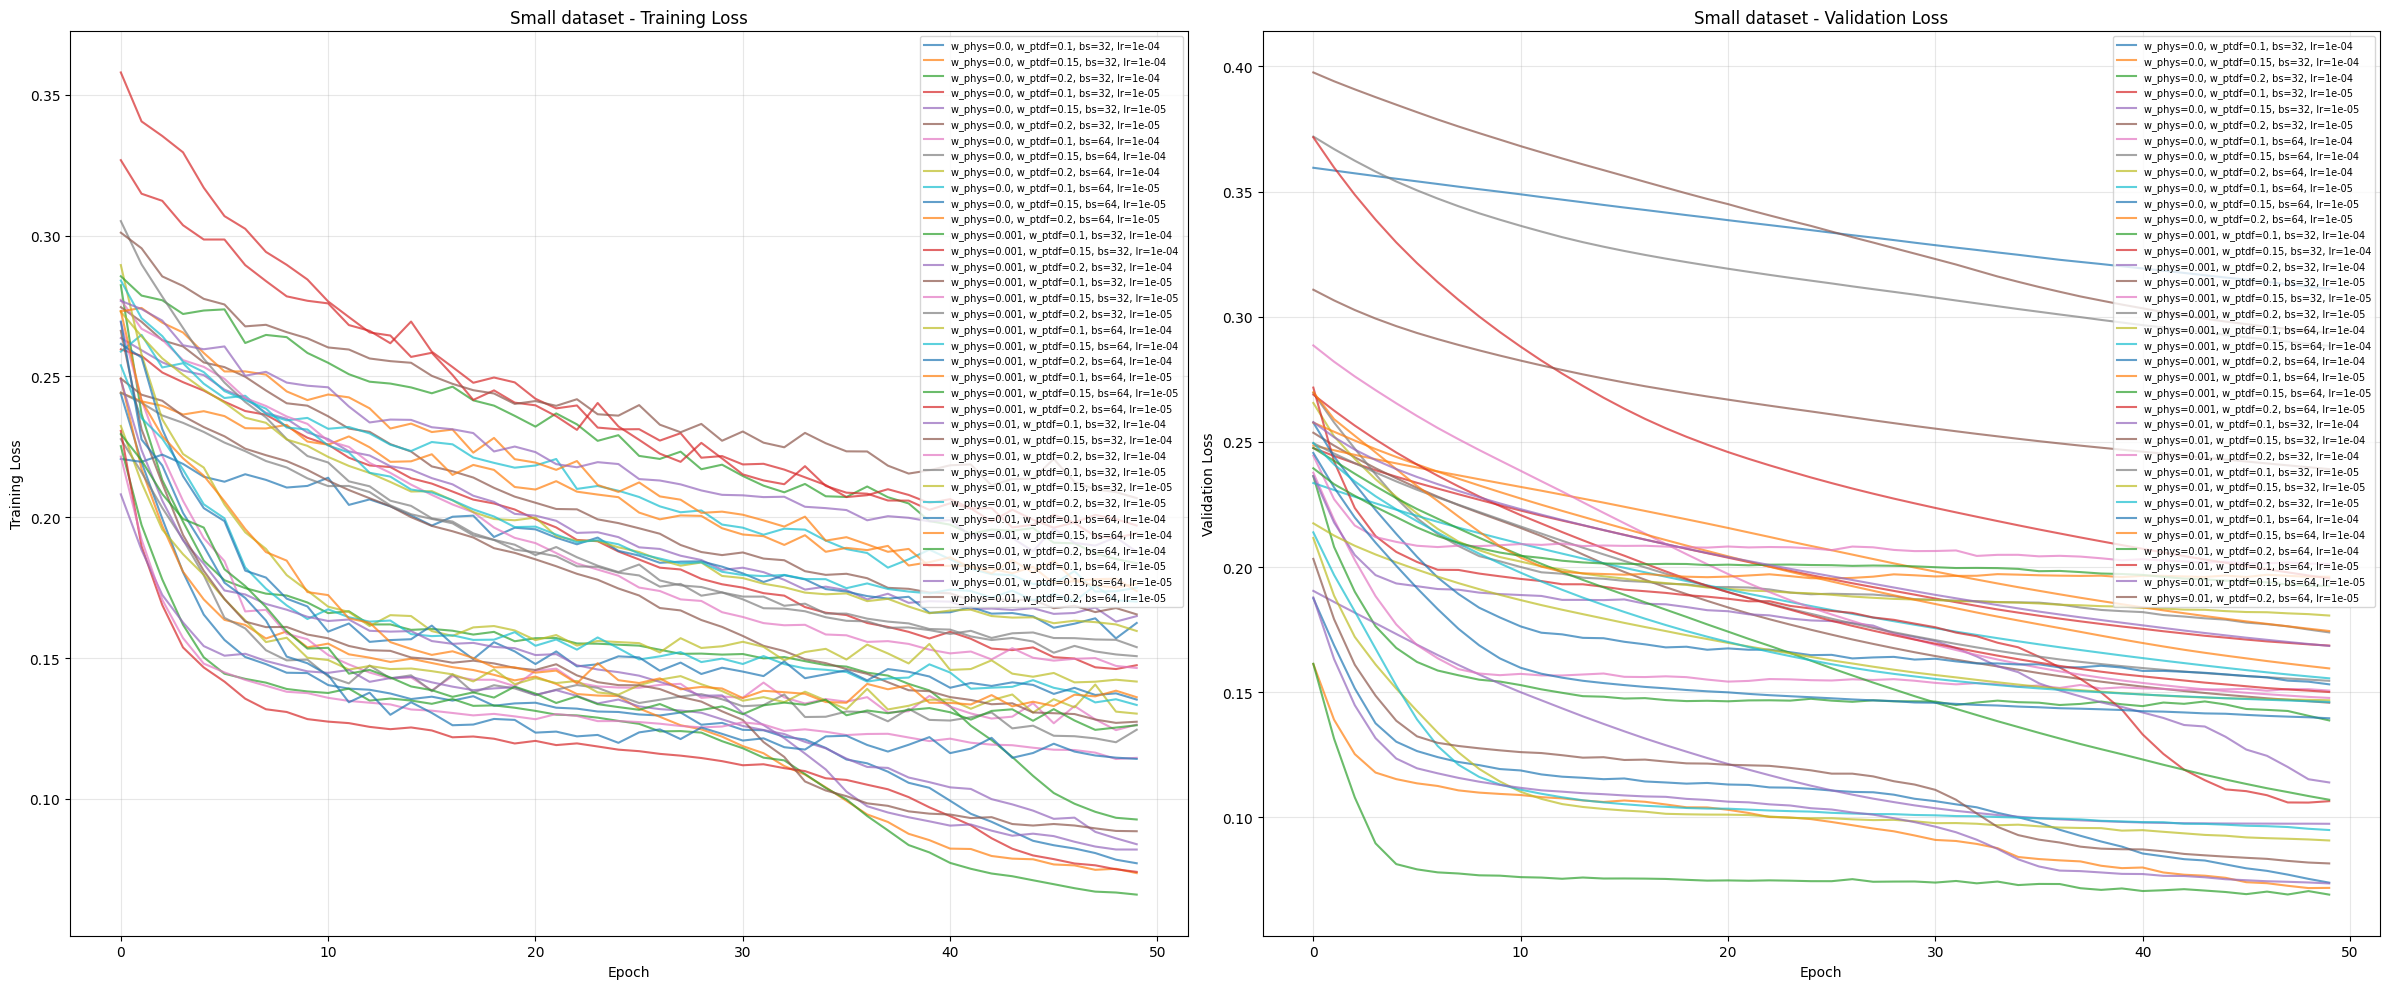

DETAILED PERFORMANCE COMPARISON
  tag  w_phys  w_ptdf  bs  lr  train_loss  val_loss  test_total  test_mse  test_physics  test_ptdf  training_time
small     .6f     .6f  32 .6f         .6f       .6f         .6f       .6f           .6f        .6f            .6f
small     .6f     .6f  32 .6f         .6f       .6f         .6f       .6f           .6f        .6f            .6f
small     .6f     .6f  32 .6f         .6f       .6f         .6f       .6f           .6f        .6f            .6f
small     .6f     .6f  32 .6f         .6f       .6f         .6f       .6f           .6f        .6f            .6f
small     .6f     .6f  32 .6f         .6f       .6f         .6f       .6f           .6f        .6f            .6f
small     .6f     .6f  32 .6f         .6f       .6f         .6f       .6f           .6f        .6f            .6f
small     .6f     .6f  64 .6f         .6f       .6f         .6f       .6f           .6f        .6f            .6f
small     .6f     .6f  64 .6f         .6f       .6f     

In [29]:
# ---- Small sweep ----
runs_small = run_hparam_sweep(
    networks=networks_small,
    physics_weights=[0.0, 0.001, 0.01],
    batch_sizes=[32, 64],
    learning_rates=[1e-4, 1e-5],
    ptdf_weights=[0.1, 0.15, 0.2],
    num_epochs=50,
    tag="small",
    verbose=False,
    save_path="training_results_saved/saved_runs_small_intermediate.pkl",
)

print_sweep_summary(runs_small, top_n=5)
plot_all_runs_training_curves(runs_small, title_prefix="Small dataset")

comparison_df = create_comparison_dataframe(runs_small)
print("=" * 80)
print("DETAILED PERFORMANCE COMPARISON")
print("=" * 80)
print(comparison_df.to_string(index=False, float_format=".6f"))

# ---- Load previously saved large sweep ----
# with open("training_results/saved_runs_large_intermediate.pkl", "rb") as f:
#     runs_large = pickle.load(f)

CWD: c:\git_repos\Graph-Neural-Networks
Path: training_results_saved\best_model_w0.001_pt0.15_bs64_lr0.0001.pt
Dir exists: True
File exists: True
Dir writable: True


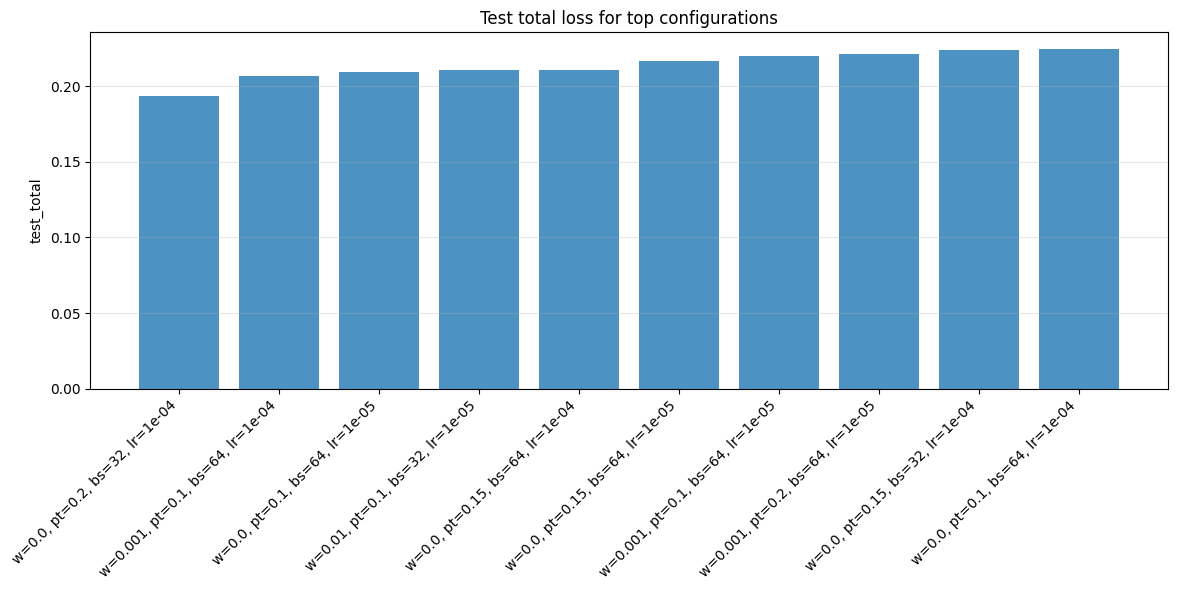

Evaluating 36 models on one test network...
  Model 'w=0.0, pt=0.1, bs=32, lr=1e-04'
  Model 'w=0.0, pt=0.15, bs=32, lr=1e-04'
  Model 'w=0.0, pt=0.2, bs=32, lr=1e-04'
  Model 'w=0.0, pt=0.1, bs=32, lr=1e-05'
  Model 'w=0.0, pt=0.15, bs=32, lr=1e-05'
  Model 'w=0.0, pt=0.2, bs=32, lr=1e-05'
  Model 'w=0.0, pt=0.1, bs=64, lr=1e-04'
  Model 'w=0.0, pt=0.15, bs=64, lr=1e-04'
  Model 'w=0.0, pt=0.2, bs=64, lr=1e-04'
  Model 'w=0.0, pt=0.1, bs=64, lr=1e-05'
  Model 'w=0.0, pt=0.15, bs=64, lr=1e-05'
  Model 'w=0.0, pt=0.2, bs=64, lr=1e-05'
  Model 'w=0.001, pt=0.1, bs=32, lr=1e-04'
  Model 'w=0.001, pt=0.15, bs=32, lr=1e-04'
  Model 'w=0.001, pt=0.2, bs=32, lr=1e-04'
  Model 'w=0.001, pt=0.1, bs=32, lr=1e-05'
  Model 'w=0.001, pt=0.15, bs=32, lr=1e-05'
  Model 'w=0.001, pt=0.2, bs=32, lr=1e-05'
  Model 'w=0.001, pt=0.1, bs=64, lr=1e-04'
  Model 'w=0.001, pt=0.15, bs=64, lr=1e-04'
  Model 'w=0.001, pt=0.2, bs=64, lr=1e-04'
  Model 'w=0.001, pt=0.1, bs=64, lr=1e-05'
  Model 'w=0.001, pt=0.15, 

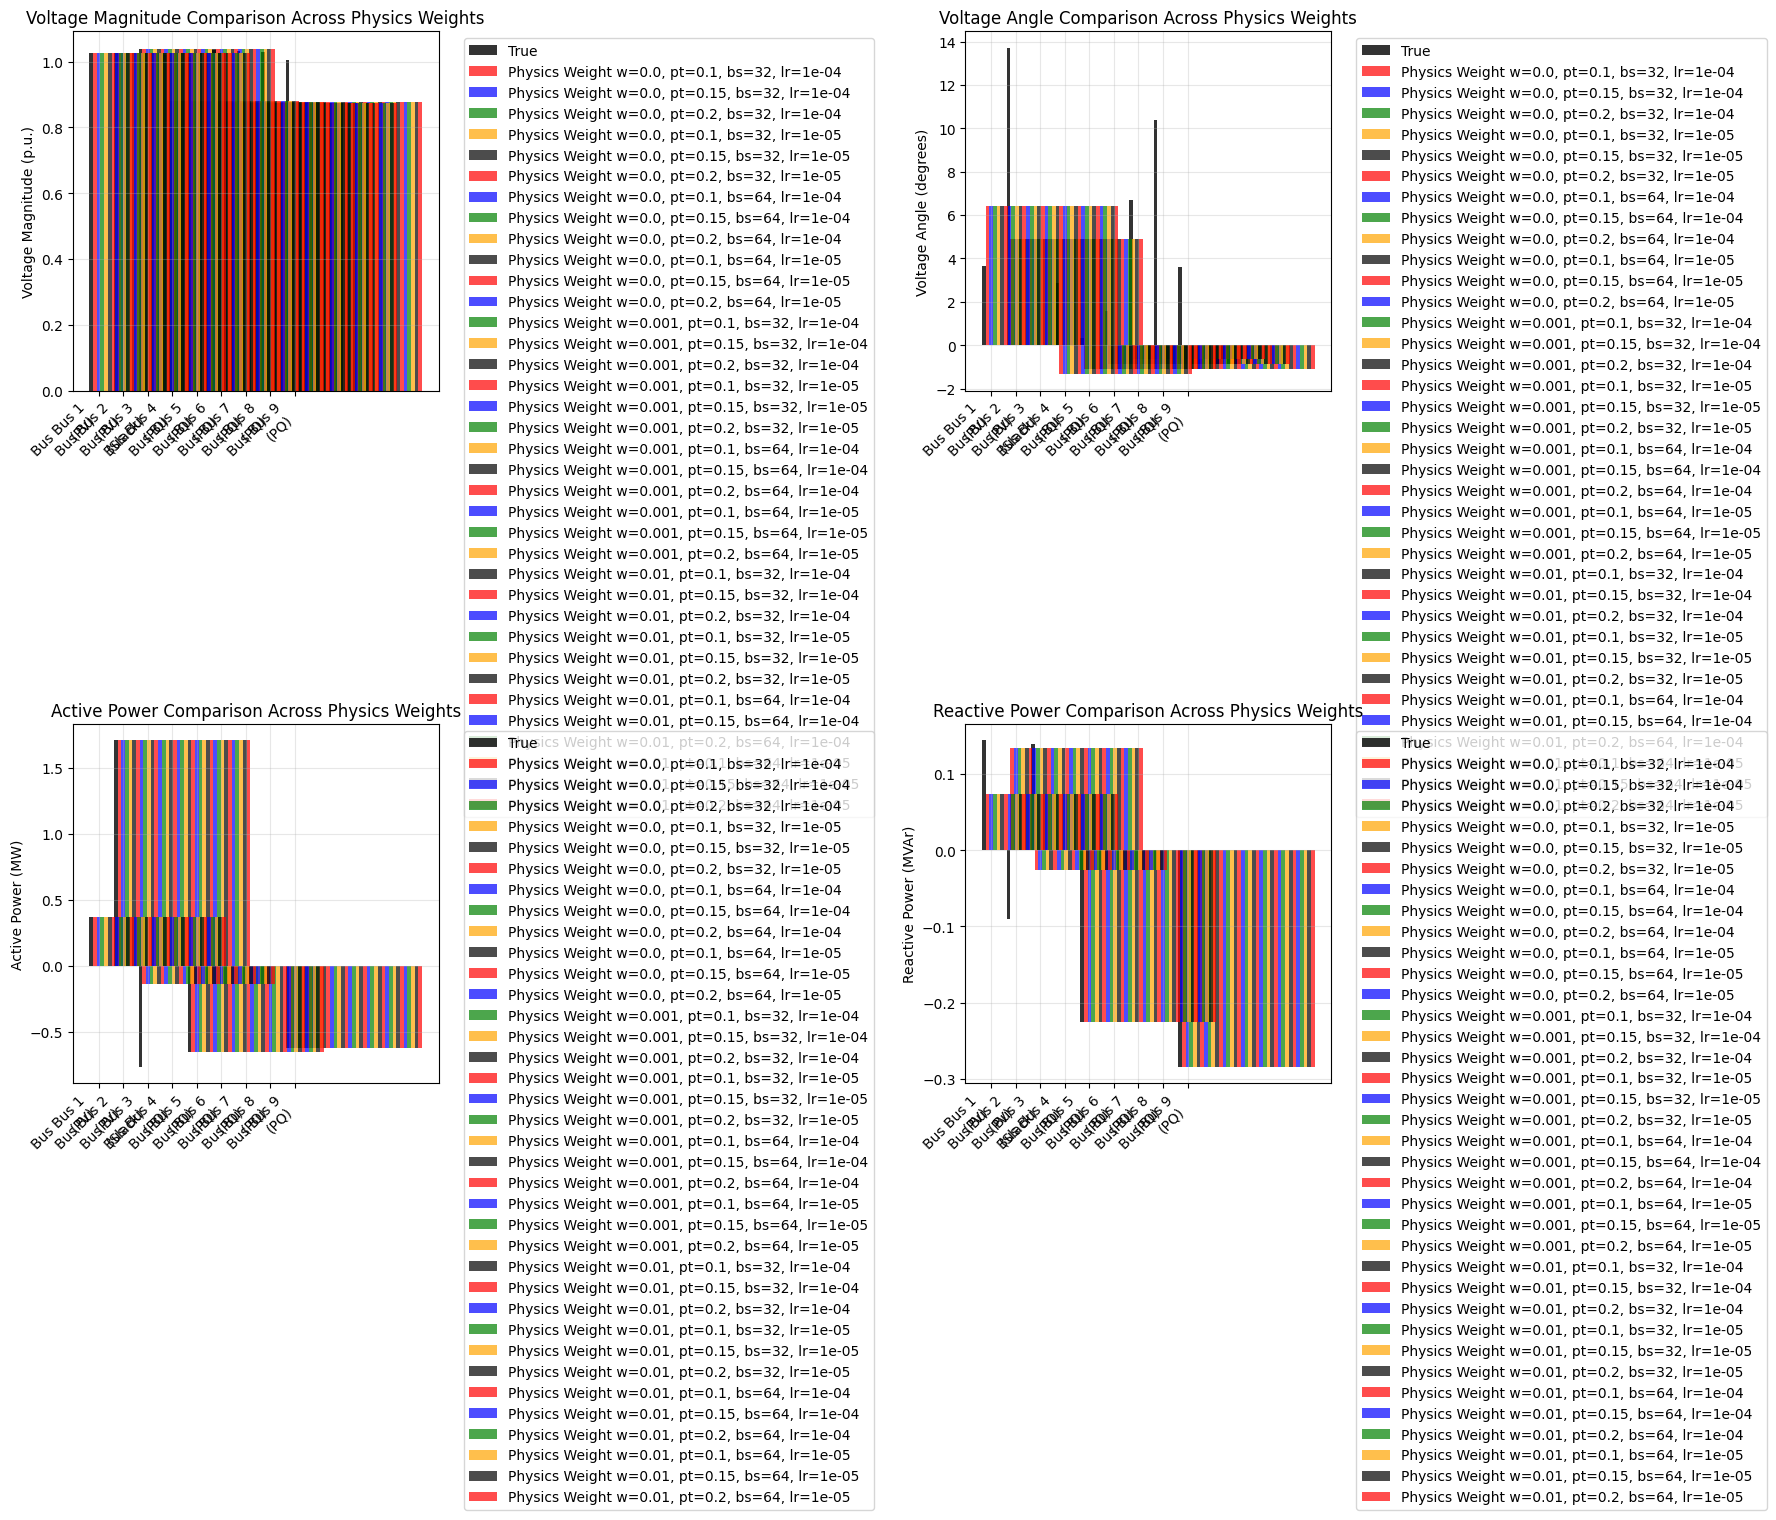

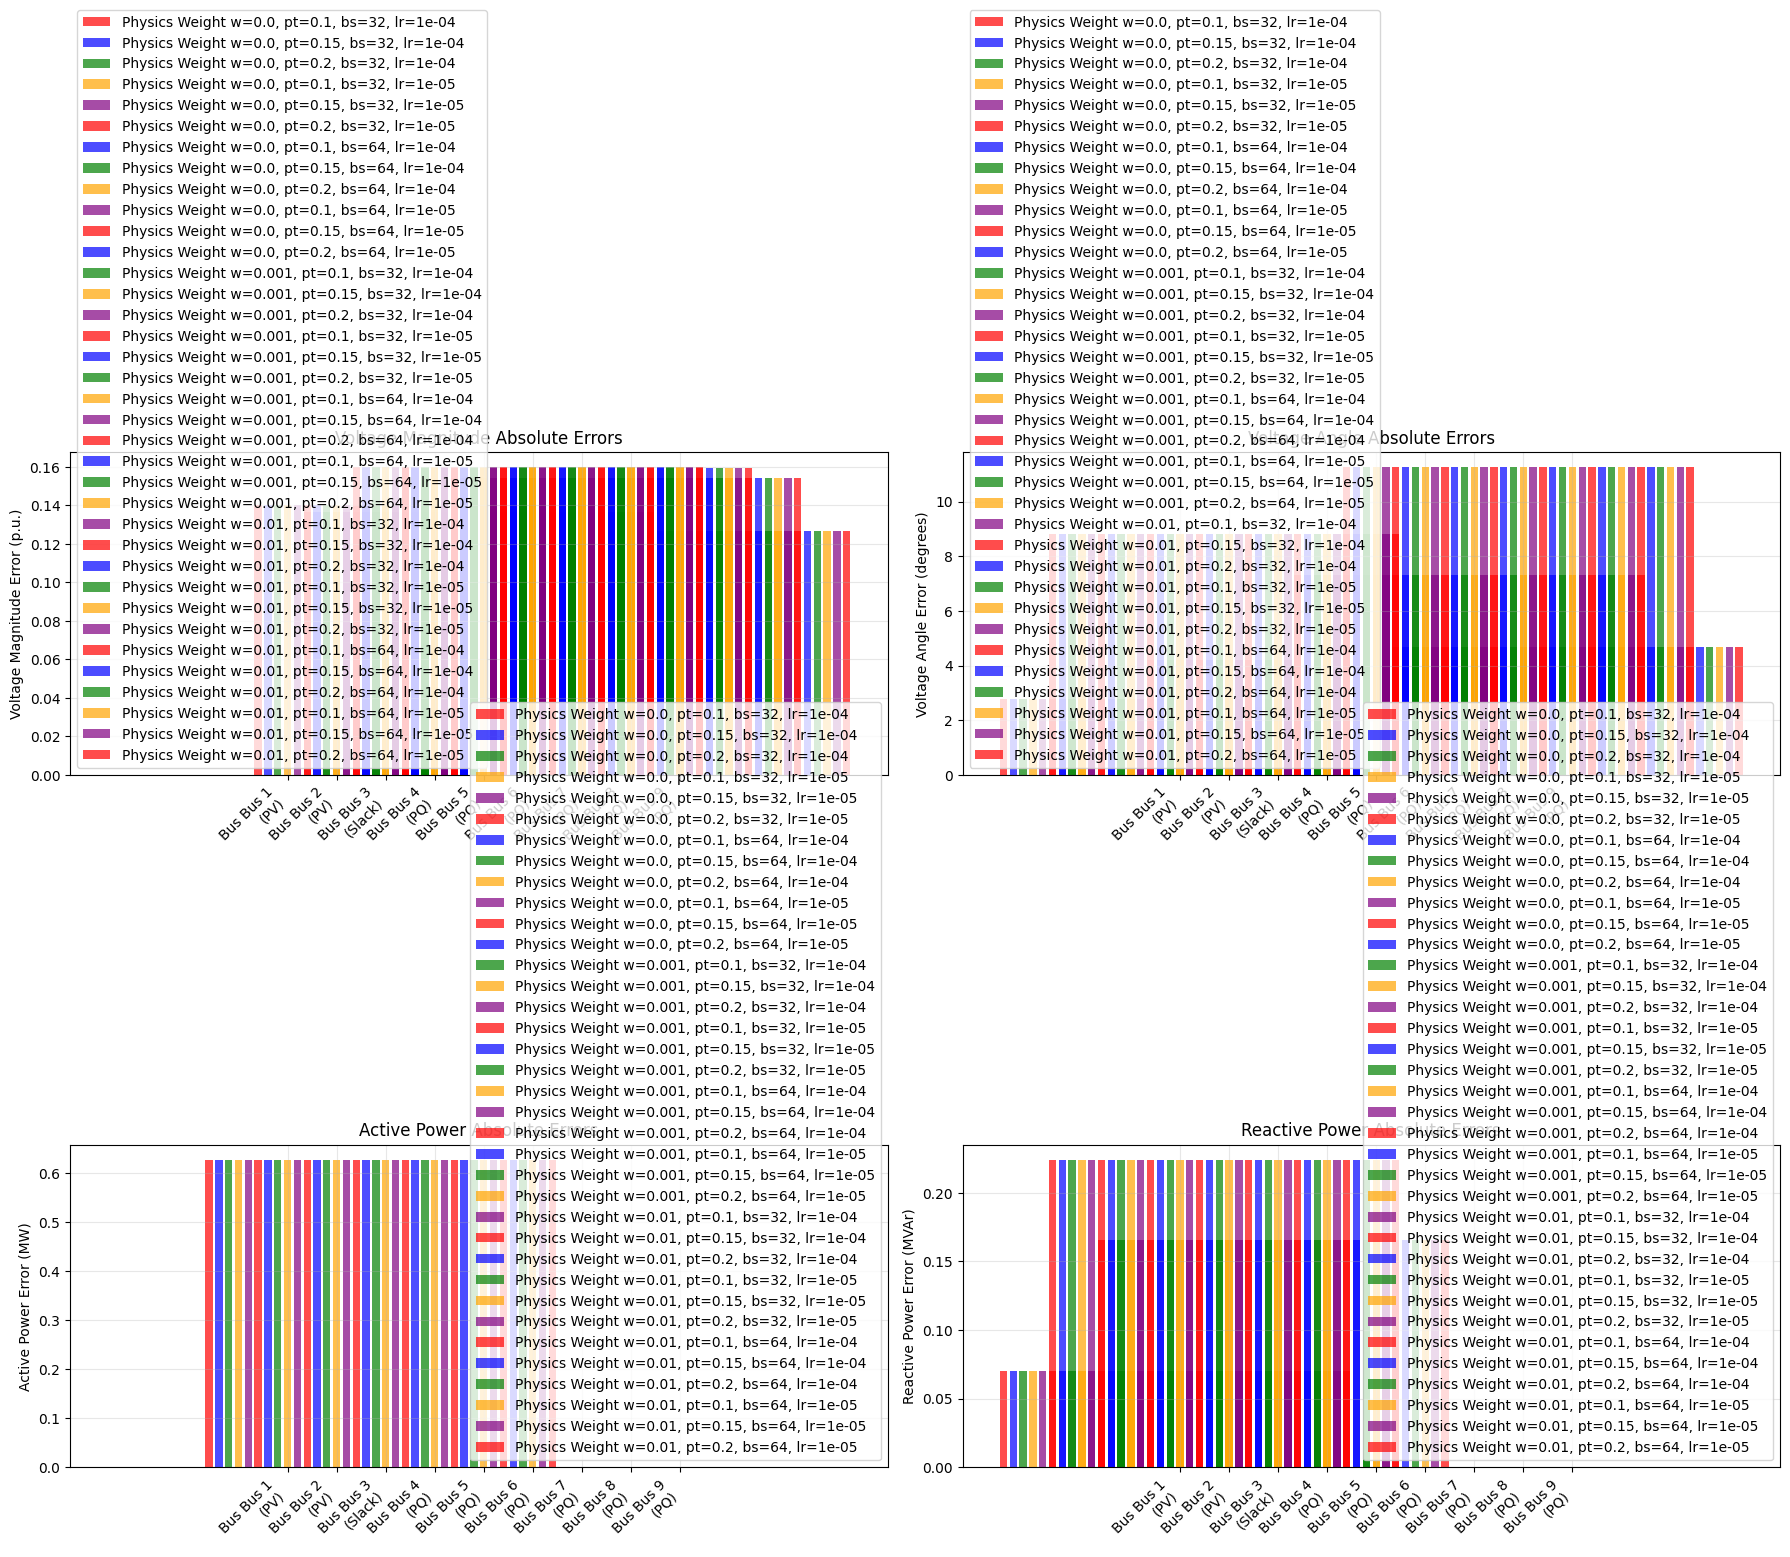

PHYSICS LOSS COMPARISON SUMMARY
Metric              Physics w=0.0, pt=0.1, bs=32, lr=1e-04Physics w=0.0, pt=0.15, bs=32, lr=1e-04Physics w=0.0, pt=0.2, bs=32, lr=1e-04Physics w=0.0, pt=0.1, bs=32, lr=1e-05Physics w=0.0, pt=0.15, bs=32, lr=1e-05Physics w=0.0, pt=0.2, bs=32, lr=1e-05Physics w=0.0, pt=0.1, bs=64, lr=1e-04Physics w=0.0, pt=0.15, bs=64, lr=1e-04Physics w=0.0, pt=0.2, bs=64, lr=1e-04Physics w=0.0, pt=0.1, bs=64, lr=1e-05Physics w=0.0, pt=0.15, bs=64, lr=1e-05Physics w=0.0, pt=0.2, bs=64, lr=1e-05Physics w=0.001, pt=0.1, bs=32, lr=1e-04Physics w=0.001, pt=0.15, bs=32, lr=1e-04Physics w=0.001, pt=0.2, bs=32, lr=1e-04Physics w=0.001, pt=0.1, bs=32, lr=1e-05Physics w=0.001, pt=0.15, bs=32, lr=1e-05Physics w=0.001, pt=0.2, bs=32, lr=1e-05Physics w=0.001, pt=0.1, bs=64, lr=1e-04Physics w=0.001, pt=0.15, bs=64, lr=1e-04Physics w=0.001, pt=0.2, bs=64, lr=1e-04Physics w=0.001, pt=0.1, bs=64, lr=1e-05Physics w=0.001, pt=0.15, bs=64, lr=1e-05Physics w=0.001, pt=0.2, bs=64, lr=1e-05Phys

In [30]:
df = create_comparison_dataframe(runs_small)
# Choose a representative test network
test_net = networks_small[0]
test_runs=runs_small

plot_test_metrics_barchart(
    df,
    metric="test_total",
    top_n=10,
    title="Test total loss for top configurations",
)


test_net = networks_small[0]
plot_single_network_comparisons(
    test_runs,
    test_network=test_net,
    mode="all_runs",
)
